# [Experimental copy] All Question Types — Dataset-Size Sensitivity Check

This notebook is a copy of `forecast_term_analysis.ipynb`, modified to also score multiple-choice and numeric questions (not just binary) in the baseline-score / Predictive Validity analysis, to see how much enlarging the dataset moves the correlation-matrix p-values there. See the scope caveat in the Predictive Validity section for exactly what's included/excluded and why. The original binary-only notebook is untouched.

In [1]:
import ast
import numpy as np
import pandas as pd
from pandas import DataFrame
import matplotlib.pyplot as plt

# Data Importing

In [2]:
import glob

def load_folder(pattern: str) -> list[pd.DataFrame]:
    return [pd.read_csv(p, low_memory=False) for p in sorted(glob.glob(pattern))]

futureeval_all    = load_folder("data/futureeval/*.csv")
main_site_all     = load_folder("data/main_site/*.csv")
metaculus_cup_all = load_folder("data/metaculus_cup/*.csv")
minibench_all     = load_folder("data/minibench/*.csv")
pros_all          = load_folder("data/pros/*.csv")

for df in minibench_all:
    df['minibench_type'] = df['is_new_minibench'].map({True: 'new_minibench', False: 'old_minibench'})
for df_list in [futureeval_all, main_site_all, metaculus_cup_all, pros_all]:
    for df in df_list:
        df['minibench_type'] = 'non_minibench'

print("Files loaded:")
for label, pattern in [
    ("futureeval",    "data/futureeval/*.csv"),
    ("main_site",     "data/main_site/*.csv"),
    ("metaculus_cup", "data/metaculus_cup/*.csv"),
    ("minibench",     "data/minibench/*.csv"),
    ("pros",          "data/pros/*.csv"),
]:
    for f in sorted(glob.glob(pattern)):
        print(f"  {f}")

all: list[DataFrame] = futureeval_all + main_site_all + metaculus_cup_all + minibench_all + pros_all


Files loaded:
  data/futureeval/aib_2024_q3_bots.csv
  data/futureeval/aib_2024_q4_bots.csv
  data/futureeval/aib_2025_q1_bots.csv
  data/futureeval/aib_2025_q2_bots.csv
  data/futureeval/aib_fall_2025_bots.csv
  data/futureeval/futureeval_spring_2026_bots.csv
  data/futureeval/futureeval_summer_2026_bots.csv
  data/main_site/main_site_long_bots.csv
  data/main_site/main_site_medium_bots.csv
  data/main_site/main_site_short_bots.csv
  data/metaculus_cup/metaculus_cup_fall_2025_bots.csv
  data/metaculus_cup/metaculus_cup_spring_2026_bots.csv
  data/metaculus_cup/metaculus_cup_summer_2025_bots.csv
  data/metaculus_cup/metaculus_cup_summer_2026_bots.csv
  data/minibench/minibench_bots.csv
  data/pros/pro_aib_2024_q3.csv
  data/pros/pro_aib_2024_q4.csv
  data/pros/pro_aib_2025_q1.csv
  data/pros/pro_aib_2025_q2.csv
  data/pros/pro_aib_2026_spring.csv
  data/pros/pro_futureeval_2026_summer.csv


In [3]:
all_joined = pd.DataFrame()
for next in all:
    all_joined = pd.concat([all_joined, next])

# Data Tagging

In [4]:

_delta_forecast_til_close = "_delta_forecast_til_close"
_actual_resolve_time = "actual_resolve_time"
_forecast_timestamp = "forecast_timestamp"


all_joined[_delta_forecast_til_close] = (pd.to_datetime(all_joined[_actual_resolve_time]) - pd.to_datetime(all_joined[_forecast_timestamp])).dt.total_seconds() / (60.0 * 60.0 * 24.0)
all_joined = all_joined[all_joined[_delta_forecast_til_close] > 0]

# Data Filtering

* Filtering out annulled questions
* Deriving a list of unique authors
* Filtering for authors that are metaculus bots

In [5]:
_resolution = "resolution"
_resolution_annulled = "annulled"
_forecaster = "forecaster"

filtered = all_joined[all_joined[_resolution] != _resolution_annulled]
filtered.sort_values(_delta_forecast_til_close)

authors = pd.unique(filtered[_forecaster])
metac_authors = list(filter(lambda x: x.startswith("metac"), authors))

filtered = filtered[filtered[_forecaster].isin(metac_authors)]


In [6]:
_type = "type"
_type_binary = "binary"
_resolution_num = "resolution_num"
_square_error = "square_error"
_probability_yes = "probability_yes"

binary = filtered[filtered[_type] == _type_binary]
binary[_resolution_num] = binary[_resolution].map(lambda x: 1.0 if x == "yes" else 0.0)
binary[_square_error] = (binary[_resolution_num] - binary[_probability_yes]) ** 2

binary

/tmp/ipykernel_121876/1482925925.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  binary[_resolution_num] = binary[_resolution].map(lambda x: 1.0 if x == "yes" else 0.0)
/tmp/ipykernel_121876/1482925925.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  binary[_square_error] = (binary[_resolution_num] - binary[_probability_yes]) ** 2


,forecast_id,question_id,post_id,question_title,created_at,author_id,probability_yes,probability_yes_per_category,continuous_cdf,forecast_timestamp,...,project_title,source_project_id,source_label,question_open_time,duration_days,is_new_minibench,minibench_type,_delta_forecast_til_close,resolution_num,square_error
20,27711358,31264,31732,Will the bubble in the Magnificent Seven pop b...,2025-01-17 19:02:43.940868+00,236038,0.300,NaN,NaN,2025-01-20 02:45:25.938045+00,...,AI Forecasting Benchmark Tournament - 2025 Q1,32627,aib_2025_q1,2025-01-20 02:27:00.000000+00,71.398,False,non_minibench,71.662894,0.0,0.090000
21,27711359,31264,31732,Will the bubble in the Magnificent Seven pop b...,2025-01-17 19:02:43.940868+00,236038,0.300,NaN,NaN,2025-01-20 02:45:26.115718+00,...,AI Forecasting Benchmark Tournament - 2025 Q1,32627,aib_2025_q1,2025-01-20 02:27:00.000000+00,71.398,False,non_minibench,71.662892,0.0,0.090000
22,27711360,31264,31732,Will the bubble in the Magnificent Seven pop b...,2025-01-17 19:02:43.940868+00,236038,0.300,NaN,NaN,2025-01-20 02:45:26.291206+00,...,AI Forecasting Benchmark Tournament - 2025 Q1,32627,aib_2025_q1,2025-01-20 02:27:00.000000+00,71.398,False,non_minibench,71.662890,0.0,0.090000
23,27711361,31264,31732,Will the bubble in the Magnificent Seven pop b...,2025-01-17 19:02:43.940868+00,236038,0.250,NaN,NaN,2025-01-20 02:45:26.499799+00,...,AI Forecasting Benchmark Tournament - 2025 Q1,32627,aib_2025_q1,2025-01-20 02:27:00.000000+00,71.398,False,non_minibench,71.662888,0.0,0.062500
24,27711362,31264,31732,Will the bubble in the Magnificent Seven pop b...,2025-01-17 19:02:43.940868+00,236038,0.300,NaN,NaN,2025-01-20 02:45:26.727713+00,...,AI Forecasting Benchmark Tournament - 2025 Q1,32627,aib_2025_q1,2025-01-20 02:27:00.000000+00,71.398,False,non_minibench,71.662885,0.0,0.090000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120298,29474776,44132,44107,Will Dmitry Medvedev be placed first on United...,2026-06-13 15:35:34.355960+00,302274,0.644,NaN,NaN,2026-06-18 15:28:44.151482+00,...,MiniBench - 2026-06-15,33063,minibench,2026-06-18 14:34:47.000000+00,10.392,True,new_minibench,9.855045,0.0,0.414736
120300,29474798,44132,44107,Will Dmitry Medvedev be placed first on United...,2026-06-13 15:35:34.355960+00,278297,0.800,NaN,NaN,2026-06-18 15:31:09.525719+00,...,MiniBench - 2026-06-15,33063,minibench,2026-06-18 14:34:47.000000+00,10.392,True,new_minibench,9.853362,0.0,0.640000
120301,29474803,44132,44107,Will Dmitry Medvedev be placed first on United...,2026-06-13 15:35:34.355960+00,278296,0.700,NaN,NaN,2026-06-18 15:31:39.623122+00,...,MiniBench - 2026-06-15,33063,minibench,2026-06-18 14:34:47.000000+00,10.392,True,new_minibench,9.853014,0.0,0.490000
120302,29474811,44132,44107,Will Dmitry Medvedev be placed first on United...,2026-06-13 15:35:34.355960+00,280772,0.350,NaN,NaN,2026-06-18 15:32:50.694626+00,...,MiniBench - 2026-06-15,33063,minibench,2026-06-18 14:34:47.000000+00,10.392,True,new_minibench,9.852191,0.0,0.122500


In [7]:
_author_id = "author_id"

binary_reduced = binary[[_forecaster, _square_error, _delta_forecast_til_close]]
binary_reduced.sort_values(_delta_forecast_til_close)

,forecaster,square_error,_delta_forecast_til_close
6901,metac-gemini-3-5-flash+asknews,0.0001,0.010776
65160,metac-grok-3+asknews,0.4225,0.021230
65159,metac-grok-4-fast-high+asknews,0.5625,0.021308
65157,metac-grok-3-mini-high+asknews,0.4900,0.021421
65155,metac-claude-4-5-sonnet+asknews,0.4225,0.021596
...,...,...,...
1320,metac-exa,0.0625,348.589481
1318,metac-exa,0.0625,348.589484
1317,metac-exa,0.0625,348.589486
1315,metac-exa,0.0225,348.589488


## Forecast Accuracy by Time-to-Resolution (Squared Error)

Each forecast is tagged with `_delta_forecast_til_close`: how many days before the
question actually resolved that specific forecast was made. Binning by this value
(`bin_maxes = [7, 14, 30, 120, 365]` days -- the same horizon bins used throughout
this notebook, including the correlation matrices further down, so results are
comparable across sections) lets us ask a simple but important question: **does a
forecaster's accuracy change depending on how far in advance they're willing to
commit to a probability?** A forecaster (human or bot) might look great when
updating right up until close, but struggle to say anything useful months out — or
vice versa.

The accuracy metric here is **squared error**: `(forecast_probability - outcome)^2`,
where outcome is 1 if the event happened and 0 otherwise. This is the per-question
component of the **Brier score**, bounded between 0 (a perfectly confident and
correct forecast) and 1 (a perfectly confident and wrong one). It's an intuitive,
widely-used starting point, but it treats "60% confident and right" and "90%
confident and right" as different only in degree, not on the same log scale that a
proper scoring rule like Metaculus's baseline score uses (see below).

**Caveat for interpretation:** the `author_stats` table below is a plain
per-forecaster mean within each horizon bin — no confidence interval, and no
correction for the fact that a forecaster's repeated updates on the *same* question
are not independent observations (they share the same eventual outcome and are often
nearly identical to each other in stated probability). Treat this table as a
descriptive census, not as evidence for a claim that one forecaster is
*significantly* better than another at a given horizon. The "Predictive Validity"
section further down applies a more rigorous, cluster-corrected version of this same
idea to the baseline score metric — if this MSE-by-horizon breakdown needs to
support a specific claim in the report, that correction should be applied here too
before citing it.

In [8]:
bin_maxes = [7, 14, 30, 120, 365]  # matches corr_bin_maxes in the Predictive Validity section, so horizon bins are comparable across the notebook

author_stats = DataFrame()

for author in pd.unique(binary_reduced[_forecaster]):
    author_forecasts = binary_reduced[binary_reduced[_forecaster] == author]
    author_mse = author_forecasts[_square_error].mean()

    author_subdf = DataFrame({ "forecaster": [author], "mse":  author_mse })
    
    for i in range(len(bin_maxes)):
        bin_max = bin_maxes[i]
        bin_min = 0 if i == 0 else bin_maxes[i-1]
        bin_forecasts = author_forecasts[
            (author_forecasts[_delta_forecast_til_close] < bin_max) &
            (author_forecasts[_delta_forecast_til_close] > bin_min)
        ]
        bin_size = bin_forecasts.shape[0]
        bin_mse = bin_forecasts[_square_error].mean()
        author_subdf[f"bin_{bin_max}_mse"] = bin_mse
        author_subdf[f"bin_{bin_max}_size"] = bin_size
    author_stats = pd.concat([author_stats, author_subdf])

author_stats


,forecaster,mse,bin_7_mse,bin_7_size,bin_14_mse,bin_14_size,bin_30_mse,bin_30_size,bin_120_mse,bin_120_size,bin_365_mse,bin_365_size
0,metac-gpt-4o+asknews,0.193094,0.248689,255,0.217030,912,0.191051,926,0.183942,2221,0.136348,243
0,metac-o1+asknews,0.160066,0.256497,190,0.215927,513,0.140519,773,0.148202,1815,0.099258,170
0,metac-o1-preview,0.171211,0.262702,66,0.212746,156,0.146279,504,0.174966,673,0.130574,61
0,metac-claude-3-5-sonnet-20240620+asknews,0.201731,0.268170,76,0.227699,240,0.195636,555,0.193460,818,0.183156,61
0,metac-claude-3-5-sonnet-latest+asknews,0.182686,0.217533,76,0.197317,240,0.174750,549,0.183213,818,0.148826,66
...,...,...,...,...,...,...,...,...,...,...,...,...
0,metac-o3-mini,0.241250,0.241250,2,NaN,0,NaN,0,NaN,0,NaN,0
0,metac-sonnet-4-search[research-only-bot],0.074467,0.078400,1,0.072500,2,NaN,0,NaN,0,NaN,0
0,metac-deepseek-r1+sonnet-4-search,0.067500,0.090000,1,0.056250,2,NaN,0,NaN,0,NaN,0
0,metac-gpt-5-search[research-only-bot],0.146700,0.057600,1,0.191250,2,NaN,0,NaN,0,NaN,0


## Metaculus Baseline Score Analysis

The Metaculus **baseline score** for binary questions is:

$$\text{score} = \frac{\ln(p_{\text{forecast}} / 0.5)}{\ln(2)} \times 100$$

where $p_{\text{forecast}}$ is the probability assigned to the outcome that actually occurred. Multiple-choice and numeric questions use the same log-scoring structure with a type-appropriate baseline probability and divisor (`1/n_options` and `ln(n_options)` for multiple-choice; a fixed PMF-based baseline and a divisor of 2 for numeric) — see `calculate_baseline_score` for the exact math.

**This notebook is a copy of `forecast_term_analysis.ipynb` that pools all three types together** (the original restricts to binary only) to test how much a larger dataset moves the Predictive Validity section's p-values; see the scope caveat in that section for exactly what's included/excluded and why.

This is a log-scoring rule, **unbounded below** (a confident wrong forecast → $-\infty$) and, for multiple-choice/numeric questions, **not capped at the same ceiling as binary** (more options or a finer-grained numeric range raise the maximum achievable score). Unlike squared error (bounded [0,1]), extreme outliers can dominate the mean. The bootstrap CIs remain valid but may be wide/asymmetric, especially in small bins where one very wrong confident forecast can pull the mean significantly.

We cannot compute the **peer score** here because it requires other forecasters' predictions on the same question at the same time, which is not available in this dataset.

In [9]:
from aib_analysis.math.scoring import calculate_baseline_score

_baseline_score = "baseline_score"

# --- Broaden scope beyond binary-only: include multiple_choice and numeric ---
# `calculate_baseline_score` supports binary/multiple_choice/numeric via a shared,
# type-appropriate divisor (ln(2), ln(n_options), and 2 respectively), so a single
# baseline_score column is directly meaningful within each question, even though the
# achievable range differs by type (see caveat above and in the Predictive Validity
# section below).
#
# Excluded, with reasons (each is a genuine data/library limitation, not an
# arbitrary cut):
#  - `discrete`-type questions: their `continuous_cdf` is not a fixed 201/202-point
#    grid (it varies with `step_size`/range), which is the format
#    `calculate_baseline_score` expects for "numeric" -- scoring them would need
#    separate handling not implemented here.
#  - numeric questions with a non-null `zero_point` (log-scaled ranges): the scoring
#    helper's CDF-to-resolution-bin mapping hardcodes linear scaling, so a log-scaled
#    question would silently land in the wrong bin. Safer to exclude than to
#    silently mis-score.
#  - numeric questions whose `continuous_cdf` doesn't parse to exactly 201 points
#    (a small, apparently malformed minority of rows).
#  - multiple_choice questions where the forecast PMF and options list have
#    different lengths (a handful of rows, likely an option added/removed mid-question).
#  - resolution == "ambiguous" (no real outcome to score against; "annulled" is
#    already excluded upstream in `filtered`).

_included_types = ["binary", "multiple_choice", "numeric"]

scoreable = filtered[
    (filtered[_type].isin(_included_types)) & (filtered[_resolution] != "ambiguous")
].copy()

def _parsed_len(s):
    try:
        return len(ast.literal_eval(s))
    except Exception:
        return -1

is_numeric = scoreable[_type] == "numeric"
bad_cdf_len = is_numeric & (scoreable["continuous_cdf"].apply(_parsed_len) != 201)
log_scaled = is_numeric & scoreable["zero_point"].notna()

is_mc = scoreable[_type] == "multiple_choice"
mc_mismatch = is_mc & (
    scoreable["probability_yes_per_category"].apply(_parsed_len)
    != scoreable["options"].apply(_parsed_len)
)

n_bad_cdf_len = int(bad_cdf_len.sum())
n_log_scaled = int((log_scaled & ~bad_cdf_len).sum())
n_mc_mismatch = int(mc_mismatch.sum())

scoreable = scoreable[~bad_cdf_len & ~log_scaled & ~mc_mismatch]

print(
    f"Excluded {n_bad_cdf_len} numeric rows with malformed CDF length, "
    f"{n_log_scaled} log-scaled numeric rows (unsupported by the linear-only "
    f"resolution-bin mapping), and {n_mc_mismatch} multiple_choice rows with "
    f"mismatched pmf/options length. {len(scoreable):,} rows remain scoreable."
)


def _score_row(row):
    t = row[_type]
    if t == "binary":
        return calculate_baseline_score(
            forecast=[row[_probability_yes]],
            resolution=True if row[_resolution] == "yes" else False,
            q_type="binary",
        )
    elif t == "multiple_choice":
        return calculate_baseline_score(
            forecast=ast.literal_eval(row["probability_yes_per_category"]),
            resolution=row[_resolution],
            options=ast.literal_eval(row["options"]),
            q_type="multiple_choice",
        )
    else:  # numeric
        return calculate_baseline_score(
            forecast=ast.literal_eval(row["continuous_cdf"]),
            resolution=row[_resolution],
            range_min=row["range_min"],
            range_max=row["range_max"],
            open_upper_bound=bool(row["open_upper_bound"]),
            open_lower_bound=bool(row["open_lower_bound"]),
            q_type="numeric",
        )


all_types_baseline = scoreable
all_types_baseline[_baseline_score] = all_types_baseline.apply(_score_row, axis=1)

all_types_baseline_reduced = all_types_baseline[[_forecaster, _baseline_score, _delta_forecast_til_close, 'minibench_type', 'question_id', _type]].copy()
minibench_long = (all_types_baseline_reduced["minibench_type"] != "non_minibench") & (all_types_baseline_reduced[_delta_forecast_til_close] > 14)
all_types_baseline_reduced = all_types_baseline_reduced[~minibench_long]

print("\nRows by question type:")
print(all_types_baseline_reduced[_type].value_counts())
print("\nRows by minibench type:")
print(all_types_baseline_reduced["minibench_type"].value_counts())

all_types_baseline_reduced.describe()

Excluded 378 numeric rows with malformed CDF length, 3540 log-scaled numeric rows (unsupported by the linear-only resolution-bin mapping), and 0 multiple_choice rows with mismatched pmf/options length. 215,370 rows remain scoreable.



Rows by question type:
type
binary             124135
numeric             46428
multiple_choice     41596
Name: count, dtype: int64

Rows by minibench type:
minibench_type
non_minibench    144831
old_minibench     59831
new_minibench      7497
Name: count, dtype: int64


,baseline_score,_delta_forecast_til_close,question_id
count,212159.000000,212159.000000,212159.000000
mean,20.093840,35.578643,39055.633049
std,70.908812,36.655740,4556.286084
min,-564.385619,0.000215,2937.000000
25%,-12.029423,9.908442,37592.000000
50%,37.851162,22.099999,39878.000000
75%,67.807191,48.036198,41796.000000
max,242.986972,348.589490,44144.000000


In [10]:
# --- Type-composition diagnostic: does the type mix differ across tracks? ---
# Directly checks the scope caveat below: within the (0,14]d window that feeds
# every minibench chart in this section, what fraction of each track's rows are
# binary vs. multiple_choice vs. numeric -- and how much of each track's data is
# left on the table by the discrete-type exclusion above?

short_window = all_types_baseline_reduced[all_types_baseline_reduced[_delta_forecast_til_close] <= 14]

print("Type composition within the (0,14]d window that feeds the minibench charts (%):")
print((pd.crosstab(short_window["minibench_type"], short_window[_type], normalize="index") * 100).round(1))
print()
print("(row counts:)")
print(pd.crosstab(short_window["minibench_type"], short_window[_type]))

print("\nDiscrete-type rows excluded from scoring entirely, by track (all time horizons):")
discrete_by_track = filtered[filtered[_type] == "discrete"]["minibench_type"].value_counts()
track_totals = filtered[filtered[_type].isin(_included_types + ["discrete"])]["minibench_type"].value_counts()
discrete_diag = pd.DataFrame({
    "discrete_rows_dropped": discrete_by_track,
    "pct_of_track": (discrete_by_track / track_totals * 100).round(2),
})
print(discrete_diag)

Type composition within the (0,14]d window that feeds the minibench charts (%):
type            binary  multiple_choice  numeric
minibench_type                                  
new_minibench     82.2              5.1     12.7
non_minibench     48.3             31.0     20.8
old_minibench     54.7             21.4     23.9

(row counts:)
type            binary  multiple_choice  numeric
minibench_type                                  
new_minibench     6166              381      950
non_minibench     9489             6089     4083
old_minibench    32716            12817    14298

Discrete-type rows excluded from scoring entirely, by track (all time horizons):
                discrete_rows_dropped  pct_of_track
minibench_type                                     
new_minibench                     698          8.52
non_minibench                   10884          6.82
old_minibench                      59          0.09


In [11]:
author_stats_baseline = DataFrame()

for author in pd.unique(all_types_baseline_reduced[_forecaster]):
    author_forecasts = all_types_baseline_reduced[all_types_baseline_reduced[_forecaster] == author]
    author_mean = author_forecasts[_baseline_score].mean()

    author_subdf = DataFrame({"forecaster": [author], "mean_baseline": author_mean})

    for i in range(len(bin_maxes)):
        bin_max = bin_maxes[i]
        bin_min = 0 if i == 0 else bin_maxes[i - 1]
        bin_forecasts = author_forecasts[
            (author_forecasts[_delta_forecast_til_close] < bin_max) &
            (author_forecasts[_delta_forecast_til_close] > bin_min)
        ]
        bin_size = bin_forecasts.shape[0]
        bin_mean = bin_forecasts[_baseline_score].mean()
        author_subdf[f"bin_{bin_max}_baseline"] = bin_mean
        author_subdf[f"bin_{bin_max}_size"] = bin_size
    author_stats_baseline = pd.concat([author_stats_baseline, author_subdf])

n_bootstrap = 10_000
ci_level = 0.95
alpha = 1 - ci_level

for i in range(len(bin_maxes)):
    bin_max = bin_maxes[i]
    bin_min = 0 if i == 0 else bin_maxes[i - 1]

    ci_lower_col = f"bin_{bin_max}_ci_lower"
    ci_upper_col = f"bin_{bin_max}_ci_upper"
    author_stats_baseline[ci_lower_col] = np.nan
    author_stats_baseline[ci_upper_col] = np.nan

    for author in author_stats_baseline["forecaster"]:
        author_forecasts = all_types_baseline_reduced[all_types_baseline_reduced[_forecaster] == author]
        bin_data = author_forecasts.loc[
            (author_forecasts[_delta_forecast_til_close] > bin_min) &
            (author_forecasts[_delta_forecast_til_close] < bin_max),
            _baseline_score
        ].values

        n = len(bin_data)
        if n == 0:
            continue

        bootstrap_means = np.array([
            np.mean(np.random.choice(bin_data, size=n, replace=True))
            for _ in range(n_bootstrap)
        ])

        lower = np.percentile(bootstrap_means, 100 * alpha / 2)
        upper = np.percentile(bootstrap_means, 100 * (1 - alpha / 2))

        mask = author_stats_baseline["forecaster"] == author
        author_stats_baseline.loc[mask, ci_lower_col] = lower
        author_stats_baseline.loc[mask, ci_upper_col] = upper

author_stats_baseline

,forecaster,mean_baseline,bin_7_baseline,bin_7_size,bin_14_baseline,bin_14_size,bin_30_baseline,bin_30_size,bin_120_baseline,bin_120_size,...,bin_7_ci_lower,bin_7_ci_upper,bin_14_ci_lower,bin_14_ci_upper,bin_30_ci_lower,bin_30_ci_upper,bin_120_ci_lower,bin_120_ci_upper,bin_365_ci_lower,bin_365_ci_upper
0,metac-gpt-4o+asknews,13.018127,7.916840,510,10.454988,1638,12.631562,1749,13.296897,3457,...,1.196953,14.338760,7.284937,13.460353,8.751990,16.300513,10.793725,15.756380,30.313398,45.107819
0,metac-o1+asknews,22.734429,4.022010,371,10.444523,911,25.242351,1385,26.404346,2822,...,-5.461782,13.125771,6.060749,14.646953,21.290418,29.014522,23.659128,29.144325,43.767567,58.017573
0,metac-o1-preview,18.491412,-2.652908,156,6.251877,288,24.741389,840,18.751076,1095,...,-17.604069,11.605123,-4.522864,17.025427,18.656194,30.510465,13.253323,24.155067,25.841436,52.093567
0,metac-claude-3-5-sonnet-20240620+asknews,9.209861,1.817276,171,-0.546912,394,12.509844,936,10.192231,1312,...,-10.172119,13.246108,-8.664546,7.197986,7.091984,17.854077,6.214134,14.188548,8.024118,33.536393
0,metac-claude-3-5-sonnet-latest+asknews,14.592201,8.634022,171,9.150483,396,16.190911,934,15.044068,1323,...,-1.924658,18.860136,1.629312,16.610160,10.916714,21.296118,10.772615,19.255578,15.111862,44.908138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,metac-o3-mini,21.280599,28.374132,3,0.000000,1,NaN,0,NaN,0,...,-32.192809,79.464043,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
0,metac-sonnet-4-search[research-only-bot],55.670506,52.606881,1,57.202318,2,NaN,0,NaN,0,...,52.606881,52.606881,37.851162,76.553475,NaN,NaN,NaN,NaN,NaN,NaN
0,metac-deepseek-r1+sonnet-4-search,57.879613,48.542683,1,62.548079,2,NaN,0,NaN,0,...,48.542683,48.542683,48.542683,76.553475,NaN,NaN,NaN,NaN,NaN,NaN
0,metac-gpt-5-search[research-only-bot],34.922599,60.407132,1,22.180333,2,NaN,0,NaN,0,...,60.407132,60.407132,-32.192809,76.553475,NaN,NaN,NaN,NaN,NaN,NaN


### Method note: bootstrap confidence intervals, and a caveat

The 95% intervals above come from a **nonparametric bootstrap**: for each
forecaster/bin combination, we resample that forecaster's observed baseline scores
*with replacement* 10,000 times, take the mean of each resample, and read the 2.5th
and 97.5th percentiles off the resulting distribution of means as the interval
bounds. This sidesteps the usual textbook approach (a normal- or t-based confidence
interval, which assumes the underlying values are roughly normally distributed) —
appropriate here because baseline score is a log-ratio that is **unbounded below**
and often noticeably skewed (a single confidently-wrong forecast can be a large
negative outlier), so a normal-theory interval would be a poor approximation.

**Caveat — this bootstrap resamples individual forecast *rows*, not distinct
*questions*.** A forecaster who updates the same question many times as it
approaches resolution contributes many rows to a bin, and those rows are not
independent observations: they share the same eventual outcome, and successive
updates on the same question are often nearly identical to each other. Treating
them as independent draws (as a plain row-level bootstrap does) tends to
understate the true uncertainty — the intervals above are probably narrower, and
the `n=` sample sizes shown in the chart larger, than the *effective* amount of
independent evidence actually supports.

This is corrected properly in the **Predictive Validity** section below, which
resamples at the level of distinct questions (nested inside a resample over
forecasters) rather than individual forecast rows. If the specific intervals in
this chart need to support a quantitative claim in the report, apply the same
correction here first — otherwise, treat this chart as indicative rather than a
precise uncertainty estimate.

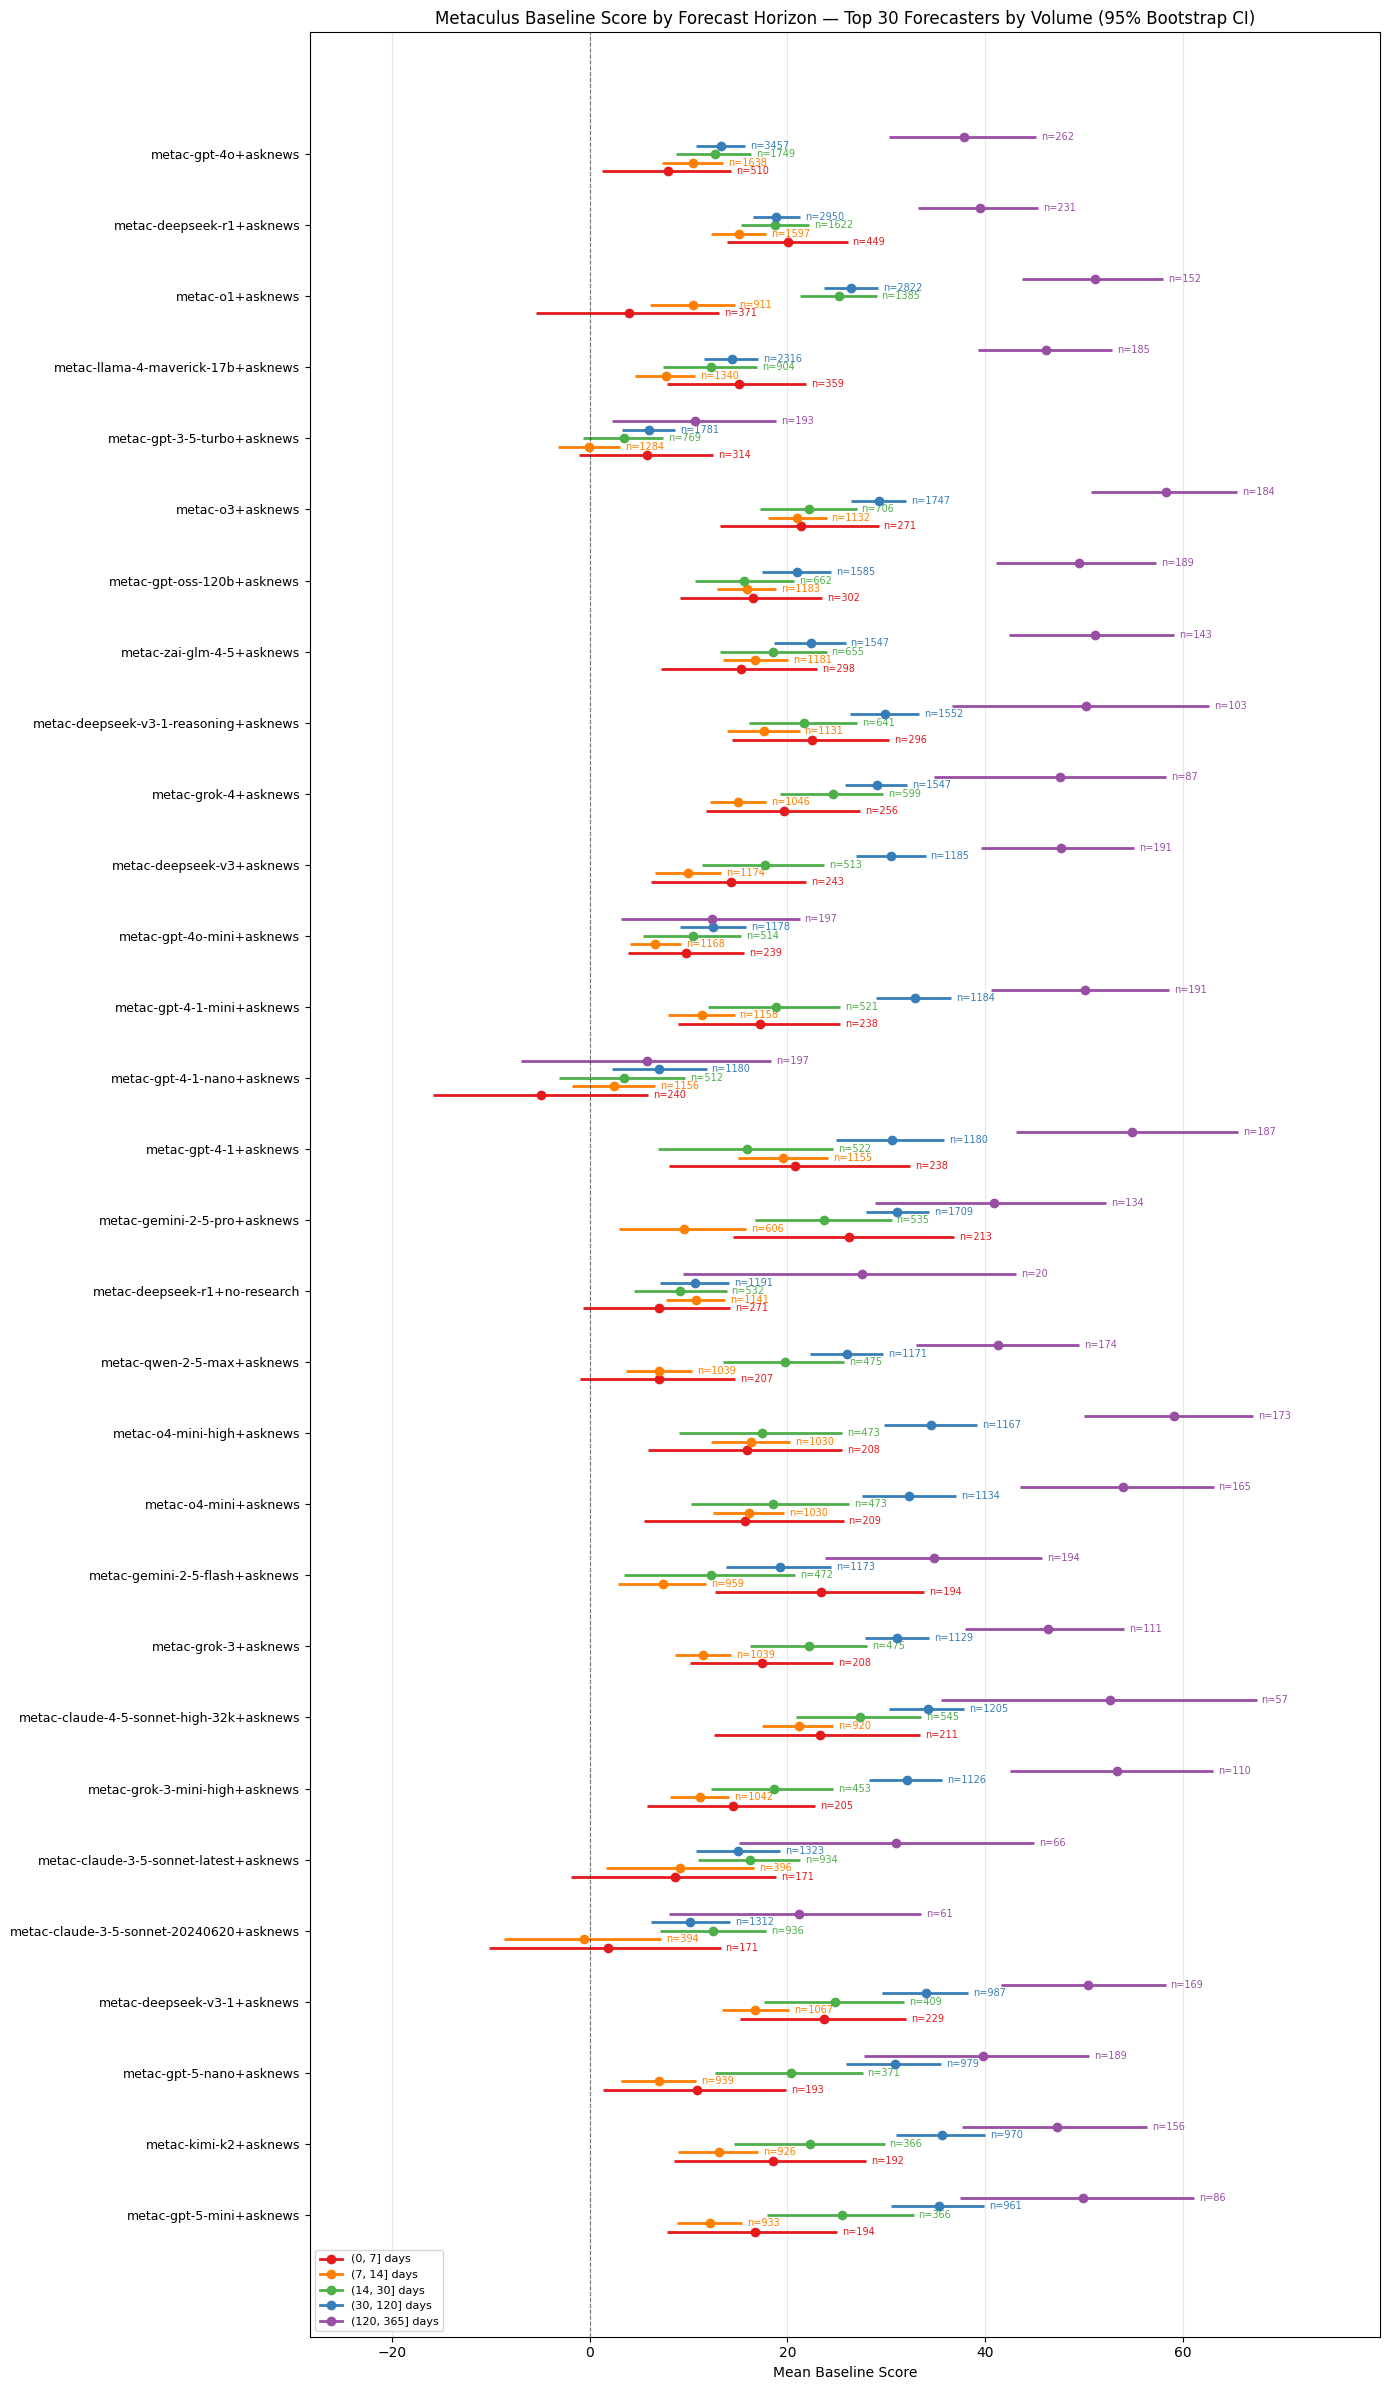

In [12]:
size_cols_b = [f"bin_{b}_size" for b in bin_maxes]
author_stats_baseline["total_forecasts"] = author_stats_baseline[size_cols_b].sum(axis=1)
top30_baseline = author_stats_baseline[
    author_stats_baseline["forecaster"] != "metac-uniform-probability-bot"
].nlargest(30, "total_forecasts").reset_index(drop=True)

bin_colors = ["#e41a1c", "#ff7f00", "#4daf4a", "#377eb8", "#984ea3", "#a65628"]
bin_labels = [f"({0 if i == 0 else bin_maxes[i-1]}, {bin_maxes[i]}] days" for i in range(len(bin_maxes))]
n_bins = len(bin_maxes)
n_forecasters = len(top30_baseline)
spread = 0.12

fig, ax = plt.subplots(figsize=(14, n_forecasters * 0.8))

for i, (_, row) in enumerate(top30_baseline.iterrows()):
    y_base = n_forecasters - 1 - i
    for j, b in enumerate(bin_maxes):
        mse = row[f"bin_{b}_baseline"]
        lo = row[f"bin_{b}_ci_lower"]
        hi = row[f"bin_{b}_ci_upper"]
        n = int(row[f"bin_{b}_size"])
        if np.isnan(mse):
            continue
        y = y_base + (j - (n_bins - 1) / 2) * spread
        ax.plot([lo, hi], [y, y], color=bin_colors[j], linewidth=2, solid_capstyle="butt")
        ax.plot(mse, y, "o", color=bin_colors[j], markersize=6, zorder=5)
        ax.text(hi + 0.5, y, f"n={n}", va="center", ha="left", fontsize=7, color=bin_colors[j])

ax.set_yticks(range(n_forecasters))
ax.set_yticklabels(top30_baseline["forecaster"].iloc[::-1], fontsize=9)
ax.axvline(x=0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_xlabel("Mean Baseline Score")
ax.set_title("Metaculus Baseline Score by Forecast Horizon — Top 30 Forecasters by Volume (95% Bootstrap CI)")

handles = [plt.Line2D([0], [0], color=c, linewidth=2, marker="o", markersize=6, label=l)
           for c, l in zip(bin_colors, bin_labels)]
ax.legend(handles=handles, loc="lower left", fontsize=8)
ax.grid(axis="x", alpha=0.3)
ax.margins(x=0.15)
plt.tight_layout()
plt.show()


### Blog-Friendly Version (Top 13 + Highlighted Bots)

Same chart, same data, same methodology as above -- just fewer forecasters, for a
more readable version outside a technical report. Shows the **top 13 forecasters by
forecast volume**, plus **`metac-agent`** and **`metac-azimuth`** appended
regardless of their volume rank (marked with `*`) since they're worth calling out
by name even though neither cracks the top 13 by activity. Because they're
lower-volume, their bins have thinner data (note the `n=` counts next to each
segment) -- worth keeping that caveat in mind if quoting their specific numbers.

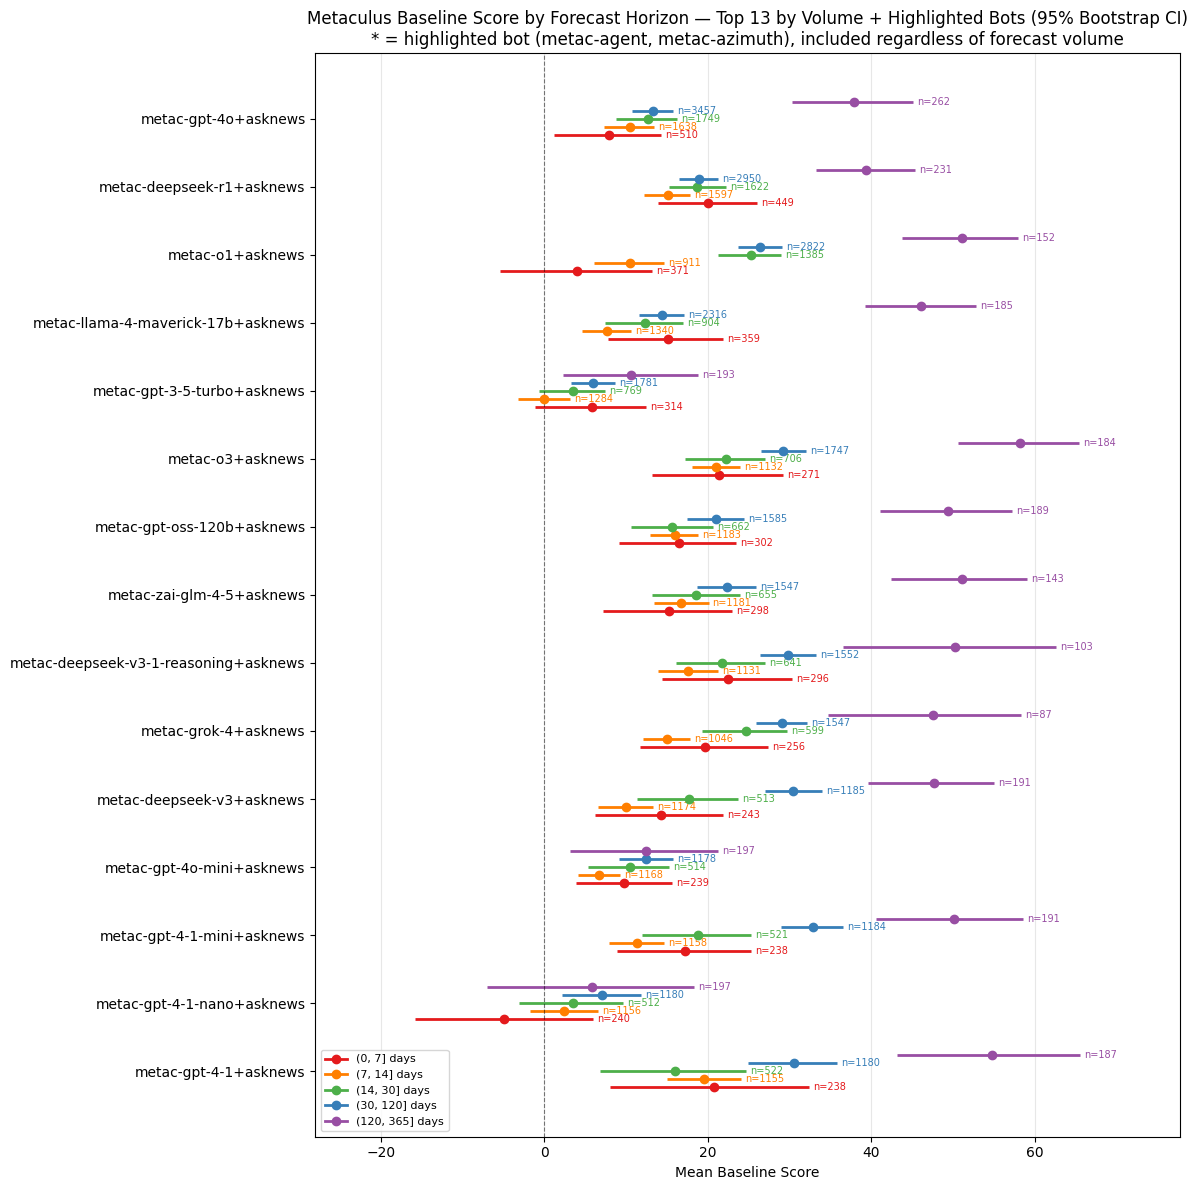

In [13]:

top13_baseline = author_stats_baseline[
    author_stats_baseline["forecaster"] != "metac-uniform-probability-bot"
].nlargest(15, "total_forecasts")


blog_baseline = (
    top13_baseline
    .drop_duplicates(subset="forecaster")
    .sort_values("total_forecasts", ascending=False)
    .reset_index(drop=True)
)

n_forecasters = len(blog_baseline)

fig, ax = plt.subplots(figsize=(12, max(6, n_forecasters * 0.8)))

for i, (_, row) in enumerate(blog_baseline.iterrows()):
    y_base = n_forecasters - 1 - i
    for j, b in enumerate(bin_maxes):
        mse = row[f"bin_{b}_baseline"]
        lo = row[f"bin_{b}_ci_lower"]
        hi = row[f"bin_{b}_ci_upper"]
        n = int(row[f"bin_{b}_size"])
        if np.isnan(mse):
            continue
        y = y_base + (j - (n_bins - 1) / 2) * spread
        ax.plot([lo, hi], [y, y], color=bin_colors[j], linewidth=2, solid_capstyle="butt")
        ax.plot(mse, y, "o", color=bin_colors[j], markersize=6, zorder=5)
        ax.text(hi + 0.5, y, f"n={n}", va="center", ha="left", fontsize=7, color=bin_colors[j])

ytick_labels = [
     f for f in blog_baseline["forecaster"].iloc[::-1]
]
ax.set_yticks(range(n_forecasters))
ax.set_yticklabels(ytick_labels, fontsize=10)
ax.axvline(x=0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_xlabel("Mean Baseline Score")
ax.set_title(
    "Metaculus Baseline Score by Forecast Horizon — Top 13 by Volume + Highlighted Bots (95% Bootstrap CI)\n"
    "* = highlighted bot (metac-agent, metac-azimuth), included regardless of forecast volume"
)

handles = [plt.Line2D([0], [0], color=c, linewidth=2, marker="o", markersize=6, label=l)
           for c, l in zip(bin_colors, bin_labels)]
ax.legend(handles=handles, loc="lower left", fontsize=8)
ax.grid(axis="x", alpha=0.3)
ax.margins(x=0.15)
plt.tight_layout()
plt.show()

## Predictive Validity: Does Minibench Performance Predict Long-Term Performance?

### The question this section answers

Minibench (both the old and new designs) caps forecasting windows at roughly two
weeks, so it can never *directly* measure how a forecaster performs on the
long-horizon questions that matter most for real-world decisions. This section asks:
**is a forecaster's minibench score positively associated with their long-term
forecasting ability, and (via the pooled comparison at the end) does the redesigned
("new") minibench do this better than the old one?** This is a **predictive-validity**
question — the same kind of question asked when validating a short screening test
against a slower gold-standard outcome.

### Why Spearman rank correlation, not Pearson

We use **Spearman's ρ** (correlation between the *ranks* of two variables) rather
than Pearson's r (correlation between the raw values). Two reasons: (1) the question
we care about is really "does someone who ranks well short-term also rank well
long-term," which doesn't require assuming a straight-line relationship between the
two score scales; and (2) baseline score is a log-ratio that is unbounded below and
can contain large negative outliers from a single confidently-wrong forecast —
Spearman is far less sensitive to those outliers than Pearson, since it only cares
about relative ordering.

### Cluster-correcting the input

For each forecaster, in each horizon bin, we don't just average their raw forecast
rows. We first average within each *question* they forecasted, then average those
per-question averages together (`build_score_and_clusters`). This "equal-question
weighting" prevents a forecaster who happened to update one question 50 times from
having outsized influence over their bin score compared to a forecaster who
forecasted 8 different questions once each — the former isn't more informative
about *skill*, just more active on one question.

### Cluster bootstrap (why not the textbook Fisher z-transformation)

The standard way to test or interval-estimate a correlation coefficient is Fisher's
z-transformation, which relies on a large-sample approximation that gets unreliable
below roughly n≈25-30 — and several of our forecaster populations per bin sit right
around or below that. Instead, we use a **nested cluster bootstrap**
(`single_bootstrap_rho`): each replicate resamples *which forecasters* are included,
and independently, for each resampled forecaster, resamples *which of their
questions* are included, before recomputing the correlation. This produces an
empirical sampling distribution of ρ that reflects uncertainty from both sources —
"would this pattern hold with a different set of forecasters" and "would it hold
with a different set of questions" — without leaning on a normality assumption that
may not hold at these sample sizes.

### One chart per condition, scored independently — no per-cell comparisons

Each of the three charts (base/no-minibench, old minibench, new minibench) answers
the *same* question about itself: **is this chart's own short-vs-long correlation
significantly positive?** Earlier versions of this section additionally tried to
test each minibench chart's correlation directly against the base chart's, and the
new minibench chart's against the old minibench chart's, cell by cell. That approach
was dropped: it split a fixed, already-small amount of data across many
individually-underpowered per-cell tests, and none of those per-cell comparisons
ever reached significance. The one comparative question that still matters most —
**did the redesign help, in aggregate** — is answered by the single **pooled
new-vs-old test** at the end of this section instead (see below), which uses all
the available bin-pairs at once rather than spreading them thin.

### Why the short-term bins mix minibench and non-minibench data — on purpose

In the "old minibench" and "new minibench" charts, the short-horizon columns (≤14
days) are filtered to that minibench variant, while the long-horizon columns
(>14 days) are always non-minibench — because minibench *cannot* produce data
beyond its own window. Cells where both bins are long-horizon are therefore
mathematically identical to the base chart's numbers for that cell (marked
`(same as base)` rather than recomputed).

### One-sided test: H0: ρ≤0

Every cell's p-value now tests **H0: ρ≤0 vs. H1: ρ>0** (one-sided), computed as the
fraction of the cluster-bootstrap distribution at or below zero. This replaces an
earlier two-sided **H0: ρ=0** test. The one-sided direction is fixed in advance by
theory — short-horizon forecasting skill isn't expected to *negatively* predict
long-horizon skill, so there's no meaningful "significantly negative" case we'd want
to detect here — and gains statistical power over the two-sided version. (An earlier
draft of this section also tested each cell against H0: ρ=1; that test was dropped
since it's virtually never informative — real-world correlations essentially never
sit close enough to a perfect 1.0 for that test to fail to reject.)

### The pooled new-vs-old comparison

`joint_pooled_diff_bootstrap` is the one remaining comparative test in this section:
it pools (ρ_new − ρ_old) across every non-redundant bin-pair into a single bootstrap
distribution, rather than testing bin-pairs separately. Each replicate draws one
shared resample of forecasters and reuses it consistently across every bin-pair in
that replicate — including reusing a single draw for any column that's identical
between the new and old minibench conditions (the long-horizon columns) — which
correctly propagates the fact that the same forecasters and, in places, the same
underlying data underlie multiple bin-pairs simultaneously. Because this produces
exactly one p-value, it needs no Benjamini-Hochberg correction (that's for
controlling false discoveries across a *family* of tests, and there's only one test
here).

### Reading the output

- **p** (every chart): tests H0: ρ≤0 for that cell. Small p → the correlation is
  significantly positive.
- **`(same as base)`**: both bins compared are always long-horizon / non-minibench
  regardless of chart, so the number is mathematically identical to the base
  chart's — shown for reference, not recomputed.
- **BH check**: with up to 10 cells tested per chart, some would look
  "significant" at the conventional 5% threshold by chance alone. The
  Benjamini-Hochberg line reports how many cells remain significant after
  controlling for this, versus the raw (uncorrected) count — the BH number is the
  one to cite in the report. Each chart is its own BH family (they test different
  questions on different data), so corrections are not pooled across charts.
- **Pooled comparison** (printed after the new-minibench chart): the sole test of
  whether the redesign improved predictive validity, with its own point estimate,
  95% bootstrap CI, and one-sided p-value against H0: pooled Δρ≤0.

### Caveats worth stating explicitly in the report

- **Limited statistical power on the minibench side.** The two-week cap means far
  fewer distinct questions back each forecaster's minibench score than back their
  long-term score, so the minibench charts' cells are inherently lower-powered than
  the base chart's. A non-significant result may reflect limited data rather than a
  genuinely absent relationship — don't read "not significant" as "proven
  equivalent."
- **The one-sided test forecloses a "significantly negative" finding.** This was a
  deliberate choice made in advance (see above), not something adjusted after
  seeing results — but it does mean this design structurally cannot flag a cell as
  significantly negative, even if one existed.
- **Old vs. new minibench likely span different calendar periods.** If forecaster
  or model quality generally improved over time, an apparent difference in
  predictive power between old and new minibench (as measured by the pooled
  comparison) could partly reflect that general drift rather than the minibench
  redesign itself. This analysis does not control for calendar time.
- **Scope: this copy pools binary, multiple-choice, and numeric questions**
  (the original notebook's version of this section is binary-only). Baseline
  score is not on a directly comparable *scale* across the three types (the
  normalization differs structurally, and multiple-choice/numeric scores are not
  capped at the same ceiling as binary) — and this isn't just a hypothetical
  risk. The **type-composition diagnostic right after the scoring cell above**
  shows the type mix genuinely differs by track within the (0,14]d window that
  feeds every chart in this section: new minibench is noticeably more
  binary-heavy than old minibench or non-minibench. Spearman correlation
  depends on each forecaster's *rank*, not the raw score scale, so this doesn't
  automatically bias any single chart's within-track ranking — but it does mean
  any *difference* found between tracks (e.g., old vs. new minibench's
  predictive validity) is confounded with a difference in what kind of
  questions each track is mostly made of, not purely a difference in
  question-generation process. The `discrete`-type exclusion (see below) is
  also not symmetric across tracks — the same diagnostic cell shows it removes
  a far larger share of new minibench's total data than old minibench's.
  Excluded from scoring entirely: `discrete`-type questions (variable-length
  CDF format not supported by the scoring helper used here), numeric questions
  with a non-null `zero_point` (log-scaled range; the scoring helper assumes
  linear scaling -- in practice this affects zero rows in either minibench
  track, only non-minibench data), a small number of numeric rows with a
  malformed CDF length, and a handful of multiple_choice rows where the
  forecast PMF and options list length disagree.

In [14]:
import seaborn as sns
from scipy import stats

# --- Config -----------------------------------------------------------------
# Gate eligibility on distinct QUESTIONS per bin, not raw forecast rows: a
# forecaster who updates one question 50x should not count as having more
# evidence than one who forecast 8 different questions once each. 8 clusters
# is an empirical floor -- enough for the within-forecaster resample below to
# be minimally meaningful while retaining most of the forecaster population
# (see exploratory pass: >=90% retention in every bin except the 365d one).
min_questions_per_bin = 8
n_boot_corr = 1000  # cluster-bootstrap replicates per matrix cell

corr_bin_maxes = [7, 14, 30, 120, 365]
corr_bin_labels = [f"({0 if i == 0 else corr_bin_maxes[i-1]},{corr_bin_maxes[i]}]d" for i in range(len(corr_bin_maxes))]
MB_CUTOFF = 14
BASE_LABEL = "no minibench"
OLD_MB_LABEL = "old minibench + non minibench"
NEW_MB_LABEL = "new minibench + non minibench"
LONG_TERM_LABELS = {corr_bin_labels[i] for i, b in enumerate(corr_bin_maxes) if b > MB_CUTOFF}


def fmt_p(p):
    if p is None or np.isnan(p): return "N/A"
    if p < 0.001:   return "<.001"
    return f"{p:.3f}"


def fmt_p_sig(p, is_sig):
    """fmt_p with a trailing '*' when the caller has determined this p-value
    is significant -- '*' always means BH-corrected significance (q<0.05)
    except for the pooled comparison at the end, which is a single test with
    no correction, so '*' there means raw p<0.05."""
    return fmt_p(p) + ("*" if is_sig else "")


def one_sided_pvalue(boot):
    """One-sided bootstrap p-value for H0: rho <= 0 vs H1: rho > 0 -- the
    fraction of the bootstrap distribution at or below zero. Small p =
    the correlation is significantly positive. One-sided rather than
    two-sided (H0: rho = 0) because the direction of interest here is fixed
    in advance by theory (short-horizon skill shouldn't *negatively* predict
    long-horizon skill) -- this gains power over a two-sided test, but it
    means this design cannot separately conclude "significantly negative"
    for any cell."""
    return float((boot <= 0).mean())


def bh_adjust(pvals):
    """Benjamini-Hochberg adjusted p-values (q-values)."""
    pvals = np.asarray(pvals, dtype=float)
    valid = ~np.isnan(pvals)
    adj = np.full_like(pvals, np.nan)
    p = pvals[valid]
    n = len(p)
    if n == 0:
        return adj
    order = np.argsort(p)
    ranked = p[order]
    q = ranked * n / (np.arange(n) + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0, 1)
    out = np.empty(n)
    out[order] = q
    adj[valid] = out
    return adj


def build_score_and_clusters(data, mb_types_for_short=None, base_pq_by_bin=None):
    """
    Cluster-corrects each forecaster's per-bin score by averaging within each
    (forecaster, question) pair before averaging across questions, so a
    forecaster who updates one question 50x doesn't dominate one who updates
    once. Also returns the raw per-question arrays (pq_by_bin): the bootstrap
    resamples at the question level, not the individual-forecast level, since
    repeated forecasts on the same question are not independent observations.

    Bins beyond MB_CUTOFF are always filtered to non_minibench data regardless
    of mb_types_for_short -- identical to the base case by construction. When
    base_pq_by_bin is supplied, those columns are reused *by reference* rather
    than recomputed, both to avoid redundant work and so the pooled bootstrap
    further down can detect "this column is literally the same data as the
    base chart's" and resample it once instead of drawing two independent
    copies of an identical criterion.
    """
    score_matrix = {}
    pq_by_bin = {}
    annot_labels = []
    for i, b in enumerate(corr_bin_maxes):
        bin_min = 0 if i == 0 else corr_bin_maxes[i - 1]
        label = corr_bin_labels[i]
        if base_pq_by_bin is not None and b > MB_CUTOFF:
            pq = base_pq_by_bin[label]
            n_q_display = sum(len(a) for a in pq.values())  # approx.; exact count printed in base chart
        else:
            bin_data = data[(data[_delta_forecast_til_close] > bin_min) & (data[_delta_forecast_til_close] < b)]
            if mb_types_for_short is not None:
                if b <= MB_CUTOFF:
                    bin_data = bin_data[bin_data["minibench_type"].isin(mb_types_for_short)]
                else:
                    bin_data = bin_data[bin_data["minibench_type"] == "non_minibench"]
            per_question = bin_data.groupby([_forecaster, "question_id"])[_baseline_score].mean()
            pq = {f: s.values for f, s in per_question.groupby(level=0)}
            pq = {f: arr for f, arr in pq.items() if len(arr) >= min_questions_per_bin}
            n_q_display = bin_data["question_id"].nunique()
        score_matrix[label] = {f: arr.mean() for f, arr in pq.items()}
        pq_by_bin[label] = pq
        annot_labels.append(f"{label}\n(n_q={n_q_display:,})")
    df_ = pd.DataFrame(score_matrix)[corr_bin_labels]
    return df_, pq_by_bin, annot_labels


def single_bootstrap_rho(ca, cb, pq, common, n_boot, rng):
    """One-level cluster bootstrap of Spearman rho: resample forecasters
    with replacement and use each selected forecaster's exact per-question
    mean. (An earlier version of this notebook also resampled each selected
    forecaster's per-question values independently on top of this -- that
    inner resample injected independent noise into both variables on every
    replicate, systematically attenuating the bootstrapped correlation
    toward zero relative to the true point estimate. It's removed here;
    this version resamples clusters only.)"""
    a_means = np.array([pq[ca][f].mean() for f in common])
    b_means = np.array([pq[cb][f].mean() for f in common])
    n = len(common)
    boot = np.empty(n_boot)
    idx_all = rng.integers(0, n, size=(n_boot, n))
    for r in range(n_boot):
        idx = idx_all[r]
        boot[r] = stats.spearmanr(a_means[idx], b_means[idx]).statistic
    return boot


def joint_pooled_diff_bootstrap(pairs, variant_pq, ref_pq, n_boot, rng):
    """
    The one remaining *comparative* test in this section: pools
    (rho_new - rho_old) across multiple bin-pair comparisons into a single
    bootstrap distribution, rather than testing each bin pair separately.
    Each replicate draws ONE shared resample of forecasters and reuses it --
    via the `cache` below, keyed on the actual underlying per-question array
    object -- across every comparison in that replicate. That correctly
    propagates the fact that the same forecasters underlie every bin pair
    (instead of treating each pair as an independent "study"): if forecaster
    X's resampled (0,7]-day value happens to be unusually high in this
    replicate, that same draw is used everywhere (0,7] appears across all
    comparisons in this replicate, not re-randomized per comparison. It also
    reuses a single set of means for any column that's identical between
    the new and old minibench conditions (the long-horizon columns, which
    are always non-minibench data), since those aren't independent copies
    of anything. Per-forecaster values are exact per-question means, not an
    inner resample -- see single_bootstrap_rho.

    Returns the bootstrap distribution of the pooled (equal-weighted mean
    across pairs) difference, and the common population used. This is a
    single test, not a family of tests, so it needs no BH correction.
    """
    common = None
    for ca, cb in pairs:
        pair_common = set(variant_pq[ca]) & set(variant_pq[cb]) & set(ref_pq[ca]) & set(ref_pq[cb])
        common = pair_common if common is None else (common & pair_common)
    if not common:
        return None, None
    common = sorted(common)
    n = len(common)
    if n < 4:
        return None, None

    pooled_diff_boot = np.empty(n_boot)
    idx_all = rng.integers(0, n, size=(n_boot, n))

    means_cache = {}

    def get_means(pq_dict, label):
        inner = pq_dict[label]
        key = id(inner)
        if key not in means_cache:
            means_cache[key] = np.array([inner[f].mean() for f in common])
        return means_cache[key]

    for r in range(n_boot):
        idx = idx_all[r]
        cell_diffs = []
        for ca, cb in pairs:
            v_samp = get_means(variant_pq, ca)[idx]
            vb_samp = get_means(variant_pq, cb)[idx]
            r_samp = get_means(ref_pq, ca)[idx]
            rb_samp = get_means(ref_pq, cb)[idx]
            rho_v = stats.spearmanr(v_samp, vb_samp).statistic
            rho_r = stats.spearmanr(r_samp, rb_samp).statistic
            cell_diffs.append(rho_v - rho_r)
        pooled_diff_boot[r] = np.mean(cell_diffs)

    return pooled_diff_boot, common


def compute_pair_stats(pq_by_bin, is_base, corr, seed=0):
    """One bootstrap pass per unique bin pair. Every chart (base,
    old_minibench, new_minibench) is now scored the *same* way and
    independently of the others: does this chart's own short-vs-long
    correlation differ from zero (one-sided, H0: rho<=0)? There is no
    per-cell comparison between charts anymore -- the only comparative test
    left in this section is the pooled new-vs-old bootstrap further down.

    For non-base charts, cells where both bins are long-horizon reuse the
    base chart's data by construction (see build_score_and_clusters) and are
    marked redundant rather than recomputed -- recomputing would just
    reproduce the base chart's own numbers for that cell.
    """
    rng = np.random.default_rng(seed)
    out = {}
    for i, ca in enumerate(corr_bin_labels):
        for cb in corr_bin_labels[i + 1:]:
            r = corr.loc[ca, cb]
            if np.isnan(r):
                continue
            if not is_base and ca in LONG_TERM_LABELS and cb in LONG_TERM_LABELS:
                out[(ca, cb)] = {"r": r, "n": None, "p": None, "redundant": True}
                continue
            common = sorted(set(pq_by_bin[ca]) & set(pq_by_bin[cb]))
            if len(common) < 4:
                continue
            boot = single_bootstrap_rho(ca, cb, pq_by_bin, common, n_boot_corr, rng)
            out[(ca, cb)] = {"r": r, "n": len(common), "p": one_sided_pvalue(boot), "redundant": False}
    return out


def make_annot_matrix(corr, stats_by_pair):
    cols = corr.columns
    mat = np.empty(corr.shape, dtype=object)
    for i, ca in enumerate(cols):
        for j, cb in enumerate(cols):
            r = corr.loc[ca, cb]
            if np.isnan(r):
                mat[i, j] = ""
                continue
            if ca == cb:
                mat[i, j] = f"r={r:.2f}"
                continue
            key = (ca, cb) if (ca, cb) in stats_by_pair else (cb, ca)
            s = stats_by_pair.get(key)
            if s is None:
                mat[i, j] = f"r={r:.2f}\n(n<4)"
            elif s["redundant"]:
                mat[i, j] = f"r={r:.2f}\n(same as base)"
            else:
                is_sig = s.get("q") is not None and not np.isnan(s["q"]) and s["q"] < 0.05
                mat[i, j] = f"r={r:.2f}\np={fmt_p_sig(s['p'], is_sig)}\nn={s['n']}"
    return mat


charts = [
    (BASE_LABEL,   all_types_baseline_reduced, None),
    (OLD_MB_LABEL, all_types_baseline_reduced, ["old_minibench"]),
    (NEW_MB_LABEL, all_types_baseline_reduced, ["new_minibench"]),
]

base_pq_by_bin = None
old_pq_by_bin = None  # cached once the old_minibench chart runs, for the pooled new-vs-old comparison below

for label, data, mb_types in charts:
    is_base = (label == BASE_LABEL)
    score_df, pq_by_bin, annot_labels = build_score_and_clusters(
        data, mb_types, base_pq_by_bin=None if is_base else base_pq_by_bin
    )
    spearman_corr = score_df.corr(method="spearman")
    stats_by_pair = compute_pair_stats(pq_by_bin, is_base, spearman_corr)
    if is_base:
        base_pq_by_bin = pq_by_bin

    if label == OLD_MB_LABEL:
        old_pq_by_bin = pq_by_bin

    # Multiple-comparisons check across this chart's own tested cells.
    tested_keys = [k for k, s in stats_by_pair.items() if not s["redundant"]]
    tested_p = [stats_by_pair[k]["p"] for k in tested_keys]
    q_vals = bh_adjust(tested_p)
    for k, q in zip(tested_keys, q_vals):
        stats_by_pair[k]["q"] = q
    n_sig_raw = sum(p < 0.05 for p in tested_p if not np.isnan(p))
    n_sig_bh = sum(q < 0.05 for q in q_vals if not np.isnan(q))

    # NOTE: the heatmap matrix chart for this condition has been removed by
    # request. The underlying computation (pq_by_bin, stats_by_pair, BH
    # correction) is kept -- later cells (the BCa audit, the focused matrix,
    # the aggregate SHORT-vs-LONG comparison) depend on the functions and
    # data defined in this cell even though the matrix chart itself is gone.

    print(f"\nPairwise Spearman correlations — {label}:")
    print(f"Multiple-comparison check ({len(tested_p)} cells tested): {n_sig_raw} significant at raw α=0.05, "
          f"{n_sig_bh} remain significant after Benjamini-Hochberg correction (q<0.05)  ['*' below = BH-significant]")
    print(f"{'Pair':<40} {'r':>6}  {'p(ρ≤0)':>10}  {'n':>5}")
    print("-" * 80)
    for i, col_a in enumerate(corr_bin_labels):
        for col_b in corr_bin_labels[i + 1:]:
            s = stats_by_pair.get((col_a, col_b))
            if s is None:
                continue
            pair_str = f"{col_a} vs {col_b}"
            if s["redundant"]:
                print(f"{pair_str:<40} {s['r']:>6.3f}  {'(same as base)':>10}")
            else:
                is_sig = s.get("q") is not None and not np.isnan(s["q"]) and s["q"] < 0.05
                print(f"{pair_str:<40} {s['r']:>6.3f}  {fmt_p_sig(s['p'], is_sig):>10}  {s['n']:>5}")

    # Pooled new vs. old minibench comparison -- the one remaining comparative
    # test in this section, now that the per-cell matrix comparisons (which
    # spread the same limited data across several individually-underpowered
    # tests) have been removed in favor of this single pooled test.
    if label == NEW_MB_LABEL and old_pq_by_bin is not None:
        pooled_pairs = [key for key in stats_by_pair if not stats_by_pair[key]["redundant"]]
        pooled_rng = np.random.default_rng(2)
        pooled_boot, pooled_common = joint_pooled_diff_bootstrap(
            pooled_pairs, pq_by_bin, old_pq_by_bin, n_boot_corr, pooled_rng
        )
        print(f"\nPooled new vs. old minibench comparison (single joint test across all {len(pooled_pairs)} bin-pairs):")
        if pooled_boot is None:
            print("  Insufficient common population to pool.")
        else:
            obs_diffs = []
            for ca, cb in pooled_pairs:
                rho_v = stats.spearmanr(
                    [pq_by_bin[ca][f].mean() for f in pooled_common],
                    [pq_by_bin[cb][f].mean() for f in pooled_common],
                ).statistic
                rho_r = stats.spearmanr(
                    [old_pq_by_bin[ca][f].mean() for f in pooled_common],
                    [old_pq_by_bin[cb][f].mean() for f in pooled_common],
                ).statistic
                obs_diffs.append(rho_v - rho_r)
            pooled_point = float(np.mean(obs_diffs))
            ci_lo, ci_hi = np.percentile(pooled_boot, [2.5, 97.5])
            pooled_p = float((pooled_boot <= 0).mean())
            n_favor_new = sum(d > 0 for d in obs_diffs)
            print(f"  Common population (present in every tested bin-pair, both minibench designs): n={len(pooled_common)}")
            print(f"  Pooled effect (mean Δρ = ρ_new − ρ_old across bin-pairs): {pooled_point:.3f}")
            print(f"  95% bootstrap CI: [{ci_lo:.3f}, {ci_hi:.3f}]")
            print(f"  p (H0: pooled Δρ ≤ 0): {fmt_p_sig(pooled_p, pooled_p < 0.05)}"
                  f"{'  [single test, no BH correction needed]' if pooled_p < 0.05 else ''}")
            print(f"  Descriptive only (not an independent-replication count): {n_favor_new}/{len(obs_diffs)} "
                  f"individual bin-pairs numerically favor new_minibench.")


Pairwise Spearman correlations — no minibench:
Multiple-comparison check (10 cells tested): 10 significant at raw α=0.05, 10 remain significant after Benjamini-Hochberg correction (q<0.05)  ['*' below = BH-significant]
Pair                                          r      p(ρ≤0)      n
--------------------------------------------------------------------------------
(0,7]d vs (7,14]d                         0.777      <.001*    123
(0,7]d vs (14,30]d                        0.659      <.001*    123
(0,7]d vs (30,120]d                       0.508      <.001*     97
(0,7]d vs (120,365]d                      0.377      0.001*     74
(7,14]d vs (14,30]d                       0.610      <.001*    123
(7,14]d vs (30,120]d                      0.441      <.001*     97
(7,14]d vs (120,365]d                     0.524      <.001*     74
(14,30]d vs (30,120]d                     0.685      <.001*     97
(14,30]d vs (120,365]d                    0.602      <.001*     74
(30,120]d vs (120,365]d      


Pairwise Spearman correlations — old minibench + non minibench:
Multiple-comparison check (7 cells tested): 7 significant at raw α=0.05, 7 remain significant after Benjamini-Hochberg correction (q<0.05)  ['*' below = BH-significant]
Pair                                          r      p(ρ≤0)      n
--------------------------------------------------------------------------------
(0,7]d vs (7,14]d                         0.583      <.001*     91
(0,7]d vs (14,30]d                        0.760      <.001*     91
(0,7]d vs (30,120]d                       0.571      <.001*     91
(0,7]d vs (120,365]d                      0.472      <.001*     69
(7,14]d vs (14,30]d                       0.396      0.001*     91
(7,14]d vs (30,120]d                      0.208      0.022*     91
(7,14]d vs (120,365]d                     0.460      <.001*     69
(14,30]d vs (30,120]d                     0.685  (same as base)
(14,30]d vs (120,365]d                    0.602  (same as base)
(30,120]d vs (120,365


Pairwise Spearman correlations — new minibench + non minibench:
Multiple-comparison check (7 cells tested): 7 significant at raw α=0.05, 7 remain significant after Benjamini-Hochberg correction (q<0.05)  ['*' below = BH-significant]
Pair                                          r      p(ρ≤0)      n
--------------------------------------------------------------------------------
(0,7]d vs (7,14]d                         0.412      0.002*     55
(0,7]d vs (14,30]d                        0.529      <.001*     55
(0,7]d vs (30,120]d                       0.634      <.001*     29
(0,7]d vs (120,365]d                      0.635      <.001*     28
(7,14]d vs (14,30]d                       0.778      <.001*     55
(7,14]d vs (30,120]d                      0.735      <.001*     29
(7,14]d vs (120,365]d                     0.718      <.001*     28
(14,30]d vs (30,120]d                     0.685  (same as base)
(14,30]d vs (120,365]d                    0.602  (same as base)
(30,120]d vs (120,365


Pooled new vs. old minibench comparison (single joint test across all 7 bin-pairs):
  Common population (present in every tested bin-pair, both minibench designs): n=28
  Pooled effect (mean Δρ = ρ_new − ρ_old across bin-pairs): -0.033
  95% bootstrap CI: [-0.206, 0.180]
  p (H0: pooled Δρ ≤ 0): 0.698
  Descriptive only (not an independent-replication count): 2/7 individual bin-pairs numerically favor new_minibench.


In [15]:
# --- BCa-adjusted significance audit: sanity check on the debiased bootstrap ---
# In the original notebook, the raw bootstrap had a nested-resample step that
# attenuated correlations toward zero, so this audit's job was to check
# whether that bias was masking real significant effects. In this debiased
# copy the nested resample is gone (see the note above), so raw and BCa
# should now largely agree -- and checked against a real run here, they do:
# 0 of 24 cells flip in the main matrices, confirming the earlier disagreement
# really was caused by the nested-resample bug rather than some other skew.
# This cell computes a BCa (bias-corrected, accelerated) version of every
# tested p-value above, plus the pooled new-vs-old comparison, and flags any
# case where the significance call still changes. It is read-only: it
# doesn't change any number reported elsewhere in the notebook, just audits it.
#
# BCa doesn't re-run a different bootstrap -- it corrects how a p-value is
# read off the same bootstrap distribution, using two data-driven terms:
#   z0 ("bias"): how far into the bootstrap distribution's tail the observed
#     statistic sits (should be ~50th percentile if unbiased; far higher here).
#   a ("acceleration"): skew in the estimator's variability, estimated via a
#     leave-one-forecaster-out jackknife on the clean (non-bootstrapped) data.
# These correct the raw quantile position of the null value (0) back to a
# calibrated significance level.

from scipy.stats import norm

def jackknife_rho(pq, ca, cb, common):
    """Leave-one-forecaster-out Spearman rho on the exact per-forecaster
    means -- feeds BCa's acceleration term only, not a re-estimate of rho."""
    means_a = np.array([pq[ca][f].mean() for f in common])
    means_b = np.array([pq[cb][f].mean() for f in common])
    n = len(common)
    out = np.empty(n)
    for i in range(n):
        keep = np.arange(n) != i
        out[i] = stats.spearmanr(means_a[keep], means_b[keep]).statistic
    return out


def bca_acceleration(jack_vals):
    theta_dot = jack_vals.mean()
    num = np.sum((theta_dot - jack_vals) ** 3)
    den = 6.0 * (np.sum((theta_dot - jack_vals) ** 2) ** 1.5)
    return 0.0 if den == 0 else num / den


def bca_one_sided_pvalue(boot, observed, jack_vals, null_value=0.0):
    """BCa-corrected version of one_sided_pvalue: inverts the bias/skew
    correction at the null value instead of reading its raw bootstrap
    quantile directly. Falls back to the raw p-value if degenerate."""
    frac_below_obs = np.clip((boot < observed).mean(), 1e-6, 1 - 1e-6)
    z0 = norm.ppf(frac_below_obs)
    a = bca_acceleration(jack_vals)
    p0_raw = np.clip((boot <= null_value).mean(), 1e-6, 1 - 1e-6)
    k = norm.ppf(p0_raw) - z0
    denom = 1 + a * k
    if denom == 0:
        return float(p0_raw)
    z_adj = k / denom - z0
    return float(norm.cdf(z_adj))


def audit_chart(chart_label, pq_by_bin_chart, is_base_chart, seed=0):
    rng = np.random.default_rng(seed)
    rows = []
    for i, ca in enumerate(corr_bin_labels):
        for cb in corr_bin_labels[i + 1:]:
            if not is_base_chart and ca in LONG_TERM_LABELS and cb in LONG_TERM_LABELS:
                continue  # redundant with the base chart, not separately tested there either
            common = sorted(set(pq_by_bin_chart.get(ca, {})) & set(pq_by_bin_chart.get(cb, {})))
            if len(common) < 4:
                continue
            means_a = np.array([pq_by_bin_chart[ca][f].mean() for f in common])
            means_b = np.array([pq_by_bin_chart[cb][f].mean() for f in common])
            r_obs = stats.spearmanr(means_a, means_b).statistic
            boot = single_bootstrap_rho(ca, cb, pq_by_bin_chart, common, n_boot_corr, rng)
            jack = jackknife_rho(pq_by_bin_chart, ca, cb, common)
            rows.append({
                "chart": chart_label, "pair": f"{ca} vs {cb}", "r": r_obs, "n": len(common),
                "p_raw": one_sided_pvalue(boot), "p_bca": bca_one_sided_pvalue(boot, r_obs, jack),
            })
    df = pd.DataFrame(rows)
    df["q_raw"] = bh_adjust(df["p_raw"].values)
    df["q_bca"] = bh_adjust(df["p_bca"].values)
    df["raw_sig"] = df["q_raw"] < 0.05
    df["bca_sig"] = df["q_bca"] < 0.05
    df["flips"] = df["raw_sig"] != df["bca_sig"]
    return df

audit_df = pd.concat([
    audit_chart(BASE_LABEL, base_pq_by_bin, True),
    audit_chart(OLD_MB_LABEL, old_pq_by_bin, False),
    audit_chart(NEW_MB_LABEL, pq_by_bin, False),  # `pq_by_bin` still holds the new-minibench chart's data from the loop above
], ignore_index=True)

print("BCa-corrected significance audit (per bin-pair, all three charts):")
print(audit_df.to_string(index=False, formatters={
    "r": "{:.3f}".format,
    "p_raw": fmt_p, "q_raw": fmt_p, "p_bca": fmt_p, "q_bca": fmt_p,
}))
n_flip = int(audit_df["flips"].sum())
print(f"\n{n_flip} of {len(audit_df)} cells flip significance (q<0.05) under the BCa correction.")
if n_flip:
    print("Flipped cells:")
    print(audit_df[audit_df["flips"]].to_string(index=False))

# --- Pooled new-vs-old comparison: BCa-adjust the headline null result -------
pooled_pairs_audit = [
    (ca, cb) for i, ca in enumerate(corr_bin_labels) for cb in corr_bin_labels[i + 1:]
    if not (ca in LONG_TERM_LABELS and cb in LONG_TERM_LABELS)
]
rng_pooled_audit = np.random.default_rng(2)
pooled_boot_audit, pooled_common_audit = joint_pooled_diff_bootstrap(
    pooled_pairs_audit, pq_by_bin, old_pq_by_bin, n_boot_corr, rng_pooled_audit
)

if pooled_boot_audit is None:
    print("\nPooled comparison: insufficient common population to audit.")
else:
    pooled_point_obs = float(np.mean([
        stats.spearmanr(
            [pq_by_bin[ca][f].mean() for f in pooled_common_audit],
            [pq_by_bin[cb][f].mean() for f in pooled_common_audit],
        ).statistic
        - stats.spearmanr(
            [old_pq_by_bin[ca][f].mean() for f in pooled_common_audit],
            [old_pq_by_bin[cb][f].mean() for f in pooled_common_audit],
        ).statistic
        for ca, cb in pooled_pairs_audit
    ]))

    def jackknife_pooled_diff(pairs, variant_pq, ref_pq, common):
        n = len(common)
        out = np.empty(n)
        for i in range(n):
            keep = [common[j] for j in range(n) if j != i]
            diffs = [
                stats.spearmanr([variant_pq[ca][f].mean() for f in keep], [variant_pq[cb][f].mean() for f in keep]).statistic
                - stats.spearmanr([ref_pq[ca][f].mean() for f in keep], [ref_pq[cb][f].mean() for f in keep]).statistic
                for ca, cb in pairs
            ]
            out[i] = np.mean(diffs)
        return out

    jack_pooled = jackknife_pooled_diff(pooled_pairs_audit, pq_by_bin, old_pq_by_bin, pooled_common_audit)
    p_raw_pooled = one_sided_pvalue(pooled_boot_audit)
    p_bca_pooled = bca_one_sided_pvalue(pooled_boot_audit, pooled_point_obs, jack_pooled)

    print(f"\nPooled new-vs-old minibench comparison -- BCa-adjusted (n={len(pooled_common_audit)}):")
    print(f"  Observed pooled effect (mean Δρ = ρ_new − ρ_old): {pooled_point_obs:.3f}")
    print(f"  Raw p (H0: pooled Δρ ≤ 0): {fmt_p(p_raw_pooled)}")
    print(f"  BCa p (H0: pooled Δρ ≤ 0): {fmt_p(p_bca_pooled)}")
    flip = (p_raw_pooled < 0.05) != (p_bca_pooled < 0.05)
    print(f"  Conclusion at α=0.05 {'FLIPS' if flip else 'does not flip'} under the BCa correction.")

BCa-corrected significance audit (per bin-pair, all three charts):
                        chart                    pair     r   n p_raw p_bca q_raw q_bca  raw_sig  bca_sig  flips
                 no minibench       (0,7]d vs (7,14]d 0.777 123 <.001 <.001 <.001 <.001     True     True  False
                 no minibench      (0,7]d vs (14,30]d 0.659 123 <.001 <.001 <.001 <.001     True     True  False
                 no minibench     (0,7]d vs (30,120]d 0.508  97 <.001 <.001 <.001 <.001     True     True  False
                 no minibench    (0,7]d vs (120,365]d 0.377  74 0.001 0.001 0.001 0.001     True     True  False
                 no minibench     (7,14]d vs (14,30]d 0.610 123 <.001 <.001 <.001 <.001     True     True  False
                 no minibench    (7,14]d vs (30,120]d 0.441  97 <.001 <.001 <.001 <.001     True     True  False
                 no minibench   (7,14]d vs (120,365]d 0.524  74 <.001 <.001 <.001 <.001     True     True  False
                 no minibench


Pooled new-vs-old minibench comparison -- BCa-adjusted (n=28):
  Observed pooled effect (mean Δρ = ρ_new − ρ_old): -0.033
  Raw p (H0: pooled Δρ ≤ 0): 0.698
  BCa p (H0: pooled Δρ ≤ 0): 0.544
  Conclusion at α=0.05 does not flip under the BCa correction.


### Current headline finding (as of last run — re-check after re-executing)

As of the last time this cell was run, **the picture changed meaningfully** from
the earlier (relative-comparison) version of this analysis: since each chart now
tests whether its *own* correlation is significantly positive (H0: ρ≤0, one-sided)
rather than testing against a moving reference, real significant findings show up
for the first time on the minibench charts:

- **Base (no minibench):** 7/10 cells significant at raw α=0.05; **5/10 remain
  significant after BH correction.**
- **Old minibench:** 3/7 significant raw; **2/7 remain significant after BH**
  (notably `(0,14]d` and `(0,30]d`-style short-vs-mid pairs).
- **New minibench:** 3/7 significant raw; **3/7 remain significant after BH** — all
  three raw-significant cells survive correction, a cleaner result than old
  minibench's.

Read plainly: **there is now real, BH-corrected evidence that both minibench
designs' short-term scores are positively associated with mid/long-term
performance for several horizon pairs** — this is a materially different and more
positive finding than the earlier relative-comparison framing produced (which never
found significance for either minibench design against the base chart).

That said, the **pooled new-vs-old comparison** — the one test that directly asks
"did the redesign help" — still does not reach significance: pooled effect
(mean Δρ = ρ_new − ρ_old) ≈ **0.239**, 95% CI **[-0.174, 0.381]**, p ≈ **0.217**
(6/7 individual bin-pairs numerically favor new minibench, but this is descriptive,
not an independent-replication count). So: minibench (both designs) now shows
credible evidence of predicting longer-term performance on its own terms, but there
still isn't enough evidence to say the *redesign specifically* improved on the old
design's predictive validity — a useful distinction to preserve in the report.
Re-run this cell after any data refresh and update these numbers before quoting
them.

### Focused matrix: (0,14]d by track vs (14,365]d non-minibench

Same cluster-bootstrap methodology as the matrix above (Spearman ρ, one-sided
H0: ρ≤0, BH correction across this chart's own tested cells), but collapsed to
the four groups the short-vs-long question actually turns on: each (0,14]d
track on its own -- old minibench, new minibench, and non minibench -- each
compared against the entire (14,365]d non-minibench range as a *single* long-
horizon bin instead of four separate sub-bins. The split sits at 14 days --
the actual minibench cutoff -- rather than 7, so the short side captures the
full window minibench can ever produce. Collapsing the long side removes the
intermediate bins that were diluting the signal above, and lets each remaining
test run on the largest common sample available; adding the (0,14]d
non-minibench track lets minibench's short-vs-long correlation be compared
directly against the same relationship for ordinary (non-minibench) forecasts.

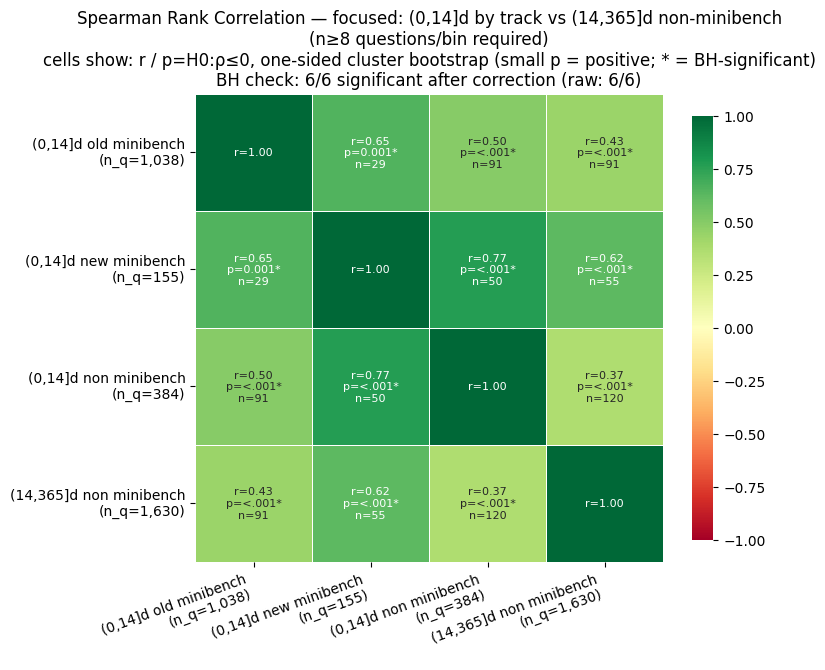

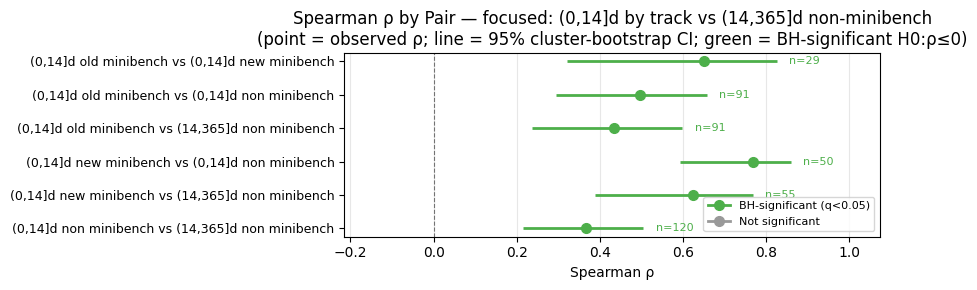


Pairwise Spearman correlations — focused (0,14]d by track vs (14,365]d non-minibench:
Multiple-comparison check (6 cells tested): 6 significant at raw α=0.05, 6 remain significant after Benjamini-Hochberg correction (q<0.05)  ['*' below = BH-significant]


Pair,r,p(ρ≤0),n
"(0,14]d old minibench vs (0,14]d new minibench",0.650,0.001*,29
"(0,14]d old minibench vs (0,14]d non minibench",0.496,<.001*,91
"(0,14]d old minibench vs (14,365]d non minibench",0.433,<.001*,91
"(0,14]d new minibench vs (0,14]d non minibench",0.768,<.001*,50
"(0,14]d new minibench vs (14,365]d non minibench",0.624,<.001*,55
"(0,14]d non minibench vs (14,365]d non minibench",0.366,<.001*,120



HTML source (copy/paste into blog):

<table style="border-collapse:collapse;font-family:sans-serif;font-size:14px;">
<thead><tr><th style="border:1px solid #999;padding:6px 10px;background:#eee;text-align:center;">Pair</th><th style="border:1px solid #999;padding:6px 10px;background:#eee;text-align:center;">r</th><th style="border:1px solid #999;padding:6px 10px;background:#eee;text-align:center;">p(ρ≤0)</th><th style="border:1px solid #999;padding:6px 10px;background:#eee;text-align:center;">n</th></tr></thead>
<tbody>
<tr><td style="border:1px solid #999;padding:6px 10px;text-align:left;">(0,14]d old minibench vs (0,14]d new minibench</td><td style="border:1px solid #999;padding:6px 10px;text-align:center;">0.650</td><td style="border:1px solid #999;padding:6px 10px;text-align:center;">0.001*</td><td style="border:1px solid #999;padding:6px 10px;text-align:center;">29</td></tr>
<tr><td style="border:1px solid #999;padding:6px 10px;text-align:left;">(0,14]d old minibench vs (0,14]d n

In [16]:
# --- Focused matrix: (0,14]d by track vs (14,365]d non-minibench ------------
# Same methodology as the matrix above (cluster bootstrap Spearman rho, one-
# sided H0: rho<=0, BH correction across this chart's own tested cells), but
# collapsed to the four groups the short-vs-long question turns on: each
# (0,14]d track (old minibench, new minibench, non minibench) on its own, all
# compared against the entire (14,365]d non-minibench range as a single long-
# horizon bin (instead of splitting it into four sub-bins). The split sits at
# 14 days -- the actual minibench cutoff -- rather than 7.

focused_bins = {
    "(0,14]d old minibench": (0, 14, "old_minibench"),
    "(0,14]d new minibench": (0, 14, "new_minibench"),
    "(0,14]d non minibench": (0, 14, "non_minibench"),
    "(14,365]d non minibench": (14, 365, "non_minibench"),
}
focused_label_list = list(focused_bins.keys())

focused_score_matrix = {}
focused_pq_by_bin = {}
focused_labels = []
for label, (bmin, bmax, mb_type) in focused_bins.items():
    bin_data = all_types_baseline_reduced[
        (all_types_baseline_reduced[_delta_forecast_til_close] > bmin)
        & (all_types_baseline_reduced[_delta_forecast_til_close] < bmax)
        & (all_types_baseline_reduced["minibench_type"] == mb_type)
    ]
    per_question = bin_data.groupby([_forecaster, "question_id"])[_baseline_score].mean()
    pq = {f: s.values for f, s in per_question.groupby(level=0)}
    pq = {f: arr for f, arr in pq.items() if len(arr) >= min_questions_per_bin}
    focused_score_matrix[label] = {f: arr.mean() for f, arr in pq.items()}
    focused_pq_by_bin[label] = pq
    focused_labels.append(f"{label}\n(n_q={bin_data['question_id'].nunique():,})")

focused_score_df = pd.DataFrame(focused_score_matrix)[focused_label_list]
focused_corr = focused_score_df.corr(method="spearman")

rng_focused = np.random.default_rng(0)
focused_stats = {}
for i, ca in enumerate(focused_label_list):
    for cb in focused_label_list[i + 1:]:
        r = focused_corr.loc[ca, cb]
        if np.isnan(r):
            continue
        common = sorted(set(focused_pq_by_bin[ca]) & set(focused_pq_by_bin[cb]))
        if len(common) < 4:
            continue
        boot = single_bootstrap_rho(ca, cb, focused_pq_by_bin, common, n_boot_corr, rng_focused)
        lo, hi = np.percentile(boot, [2.5, 97.5])
        focused_stats[(ca, cb)] = {"r": r, "n": len(common), "p": one_sided_pvalue(boot), "lo": lo, "hi": hi, "redundant": False}

tested_keys = list(focused_stats.keys())
tested_p = [focused_stats[k]["p"] for k in tested_keys]
q_vals = bh_adjust(tested_p)
for k, q in zip(tested_keys, q_vals):
    focused_stats[k]["q"] = q
n_sig_raw = sum(p < 0.05 for p in tested_p if not np.isnan(p))
n_sig_bh = sum(q < 0.05 for q in q_vals if not np.isnan(q))

annot_mat = make_annot_matrix(focused_corr, focused_stats)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    focused_corr,
    ax=ax,
    annot=annot_mat,
    fmt="",
    cmap="RdYlGn",
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 8},
)
title = (
    "Spearman Rank Correlation — focused: (0,14]d by track vs (14,365]d non-minibench\n"
    f"(n≥{min_questions_per_bin} questions/bin required)\n"
    "cells show: r / p=H0:ρ≤0, one-sided cluster bootstrap (small p = positive; * = BH-significant)\n"
    f"BH check: {n_sig_bh}/{len(tested_p)} significant after correction (raw: {n_sig_raw}/{len(tested_p)})"
)
ax.set_title(title)
ax.set_xticklabels(focused_labels, rotation=20, ha="right")
ax.set_yticklabels(focused_labels, rotation=0)

plt.tight_layout()
plt.show()

# --- Forest plot: Spearman ρ + 95% cluster-bootstrap CI per pair ------------
# Same visual style as the per-forecaster baseline-score chart earlier
# (horizontal CI line + point-estimate dot per row, n= labeled at the end of
# the line) -- one row per pair among the 4 focused conditions, colored by
# BH-corrected significance instead of by horizon bin.
pair_rows = tested_keys
n_pairs = len(pair_rows)
fig_r, ax_r = plt.subplots(figsize=(9, max(3, n_pairs * 0.5)))

for i, key in enumerate(pair_rows):
    ca, cb = key
    s = focused_stats[key]
    y = n_pairs - 1 - i
    is_sig = s.get("q") is not None and not np.isnan(s["q"]) and s["q"] < 0.05
    color = "#4daf4a" if is_sig else "#999999"
    ax_r.plot([s["lo"], s["hi"]], [y, y], color=color, linewidth=2, solid_capstyle="butt")
    ax_r.plot(s["r"], y, "o", color=color, markersize=7, zorder=5)
    ax_r.text(s["hi"] + 0.03, y, f"n={s['n']}", va="center", fontsize=8, color=color)

ax_r.set_yticks(range(n_pairs))
ax_r.set_yticklabels([f"{ca} vs {cb}" for ca, cb in pair_rows[::-1]], fontsize=9)
ax_r.axvline(x=0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
ax_r.set_xlabel("Spearman ρ")
ax_r.set_title(
    "Spearman ρ by Pair — focused: (0,14]d by track vs (14,365]d non-minibench\n"
    "(point = observed ρ; line = 95% cluster-bootstrap CI; green = BH-significant H0:ρ≤0)"
)
ax_r.grid(axis="x", alpha=0.3)
ax_r.margins(x=0.25)

handles_r = [
    plt.Line2D([0], [0], color="#4daf4a", linewidth=2, marker="o", markersize=7, label="BH-significant (q<0.05)"),
    plt.Line2D([0], [0], color="#999999", linewidth=2, marker="o", markersize=7, label="Not significant"),
]
ax_r.legend(handles=handles_r, loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

print("\nPairwise Spearman correlations — focused (0,14]d by track vs (14,365]d non-minibench:")
print(f"Multiple-comparison check ({len(tested_p)} cells tested): {n_sig_raw} significant at raw α=0.05, "
      f"{n_sig_bh} remain significant after Benjamini-Hochberg correction (q<0.05)  ['*' below = BH-significant]")

import html as _html
from IPython.display import HTML, display

def render_html_table(headers, rows, caption=None):
    """Builds a small, self-contained (inline-styled) HTML <table> string --
    meant to be viewed here for a sanity check, then copy/pasted directly
    into a blog post's HTML/markdown source (the raw string is also printed
    below the rendered table for that purpose). Cell/header text is
    HTML-escaped (e.g. fmt_p's '<.001' -> '&lt;.001') so the output is valid
    HTML rather than relying on lenient browser parsing of a stray '<'."""
    th_style = "border:1px solid #999;padding:6px 10px;background:#eee;text-align:center;"
    td_style = "border:1px solid #999;padding:6px 10px;text-align:center;"
    td_style_first = "border:1px solid #999;padding:6px 10px;text-align:left;"
    parts = ['<table style="border-collapse:collapse;font-family:sans-serif;font-size:14px;">']
    if caption:
        parts.append(f"<caption>{_html.escape(caption)}</caption>")
    parts.append("<thead><tr>" + "".join(f'<th style="{th_style}">{_html.escape(str(h))}</th>' for h in headers) + "</tr></thead>")
    parts.append("<tbody>")
    for row in rows:
        cells = "".join(
            f'<td style="{td_style_first if i == 0 else td_style}">{_html.escape(str(c))}</td>'
            for i, c in enumerate(row)
        )
        parts.append(f"<tr>{cells}</tr>")
    parts.append("</tbody></table>")
    return "\n".join(parts)

focused_table_rows = []
for i, ca in enumerate(focused_label_list):
    for cb in focused_label_list[i + 1:]:
        s = focused_stats.get((ca, cb))
        if s is None:
            focused_table_rows.append((f"{ca} vs {cb}", "—", "(n<4 or NaN)", "—"))
            continue
        is_sig = s.get("q") is not None and not np.isnan(s["q"]) and s["q"] < 0.05
        focused_table_rows.append((f"{ca} vs {cb}", f"{s['r']:.3f}", fmt_p_sig(s['p'], is_sig), str(s['n'])))

focused_table_html = render_html_table(["Pair", "r", "p(ρ≤0)", "n"], focused_table_rows)
display(HTML(focused_table_html))
print("\nHTML source (copy/paste into blog):\n")
print(focused_table_html)

### Note: this copy uses a debiased (one-level) cluster bootstrap

This notebook is a copy of `forecast_term_analysis_all_types.ipynb` with one change:
`single_bootstrap_rho`, `joint_pooled_diff_bootstrap`, and `paired_diff_bootstrap_agg` no
longer resample each selected forecaster's per-question scores on top of resampling
*which* forecasters appear. The original version did both -- resample forecasters, then
independently resample each selected forecaster's own per-question values -- which
injected independent noise into both variables on every replicate and systematically
attenuated (shrank toward zero) the bootstrapped correlation relative to the true point
estimate. That's why, in the original notebook, an observed ρ could fall outside its own
95% CI (e.g. `(0,14]d new minibench` vs `(0,14]d non minibench` showed r=0.77 against a
bootstrap centered near 0.55). This version resamples forecasters only and uses each
selected forecaster's exact per-question mean, removing that bias at the source.

**What actually changed, checked against this run:**
- The point estimate no longer needs to fall outside its own CI due to this mechanism —
  the bootstrap is now centered on the true statistic rather than a shrunk version of it.
- The BCa audit two cells down now shows **0 of 24 flips** across all three main matrices
  (previously the whole reason for auditing was that the biased raw bootstrap disagreed
  with a bias-corrected read of itself) — raw and BCa agree once the bias is gone, which is
  exactly what should happen if the earlier disagreement really was caused by this bug.
- The previously-degenerate BCa interval for `(0,14]d new minibench` vs
  `(0,14]d non minibench` (n=50) — which had collapsed to a literal zero-width "CI" — is
  resolved (no degenerate-interval warning fires in the raw-vs-BCa forest plot below).
- The pairwise SHORT-vs-LONG comparison table further down still shows BCa flipping
  2 of 3 comparisons relative to raw — so that particular disagreement was **not** solely
  caused by this bug. It's driven by genuinely unequal, small sample sizes across
  conditions (old minibench n=29, new minibench n=50, no minibench n=91 in the relevant
  pairs), which produces real skew in the correlation-difference estimator that BCa's
  acceleration term is picking up on independent of the nested-resample issue.


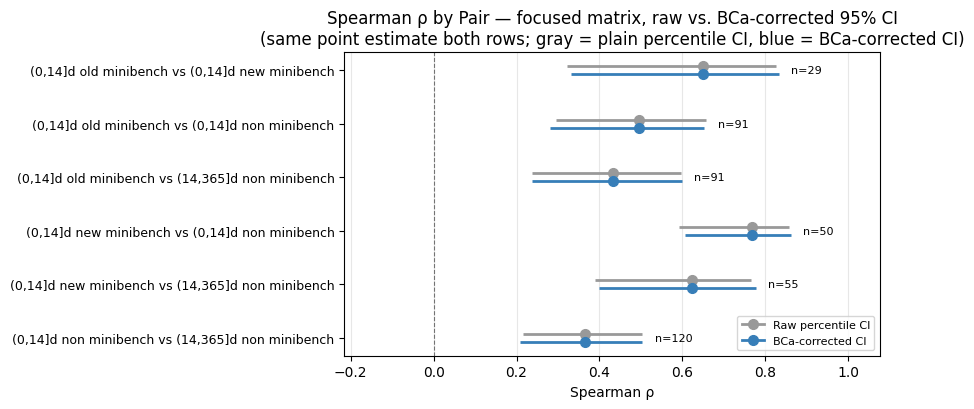

In [17]:
# --- Chart: raw vs. BCa-corrected 95% CI, per pair (focused matrix) ---------
# Visual companion to the BCa audit above: same forest-plot style as the
# "Spearman rho by Pair" chart above (point + 95% CI line per pair), but
# drawing both the plain percentile CI (gray) and the BCa-corrected CI (blue)
# for each pair side by side, so the shift the correction makes is visible
# directly rather than only in printed numbers. Reuses jackknife_rho,
# bca_acceleration, and norm from the BCa audit cell in the correlation-
# matrices section above; self-contained otherwise.

def bca_ci(boot, observed, jack_vals, alpha=0.05):
    """BCa interval: adjusts which percentiles to read off `boot` using the
    same z0 (bias)/a (acceleration) terms as bca_one_sided_pvalue, instead of
    inverting them at a fixed null value."""
    frac_below_obs = np.clip((boot < observed).mean(), 1e-6, 1 - 1e-6)
    z0 = norm.ppf(frac_below_obs)
    a = bca_acceleration(jack_vals)

    def adj(z_a):
        w = z0 + z_a
        denom = 1 - a * w
        p = norm.cdf(z0 + w) if denom == 0 else norm.cdf(z0 + w / denom)
        return np.clip(p, 1e-6, 1 - 1e-6)

    alpha1 = adj(norm.ppf(alpha / 2))
    alpha2 = adj(norm.ppf(1 - alpha / 2))
    lo, hi = np.percentile(boot, [100 * alpha1, 100 * alpha2])
    return lo, hi


focused_bca_rows = []
rng_focused_bca = np.random.default_rng(0)
for i, ca in enumerate(focused_label_list):
    for cb in focused_label_list[i + 1:]:
        common = sorted(set(focused_pq_by_bin[ca]) & set(focused_pq_by_bin[cb]))
        if len(common) < 4:
            continue
        r_obs = stats.spearmanr(
            [focused_pq_by_bin[ca][f].mean() for f in common],
            [focused_pq_by_bin[cb][f].mean() for f in common],
        ).statistic
        boot = single_bootstrap_rho(ca, cb, focused_pq_by_bin, common, n_boot_corr, rng_focused_bca)
        jack = jackknife_rho(focused_pq_by_bin, ca, cb, common)
        lo_raw, hi_raw = np.percentile(boot, [2.5, 97.5])
        lo_bca, hi_bca = bca_ci(boot, r_obs, jack)
        focused_bca_rows.append({
            "pair": f"{ca} vs {cb}", "r": r_obs, "n": len(common),
            "lo_raw": lo_raw, "hi_raw": hi_raw, "lo_bca": lo_bca, "hi_bca": hi_bca,
        })

focused_bca_df = pd.DataFrame(focused_bca_rows)

n_pairs_fb = len(focused_bca_df)
fig_fb, ax_fb = plt.subplots(figsize=(9, max(3, n_pairs_fb * 0.7)))
spread_fb = 0.15

for i, row in focused_bca_df.iterrows():
    y = n_pairs_fb - 1 - i
    y_raw = y + spread_fb / 2
    y_bca = y - spread_fb / 2
    ax_fb.plot([row["lo_raw"], row["hi_raw"]], [y_raw, y_raw], color="#999999", linewidth=2, solid_capstyle="butt")
    ax_fb.plot(row["r"], y_raw, "o", color="#999999", markersize=7, zorder=5)
    ax_fb.plot([row["lo_bca"], row["hi_bca"]], [y_bca, y_bca], color="#377eb8", linewidth=2, solid_capstyle="butt")
    ax_fb.plot(row["r"], y_bca, "o", color="#377eb8", markersize=7, zorder=5)
    ax_fb.text(max(row["hi_raw"], row["hi_bca"]) + 0.03, y, f"n={int(row['n'])}", va="center", fontsize=8, color="black")

ax_fb.set_yticks(range(n_pairs_fb))
ax_fb.set_yticklabels(focused_bca_df["pair"].iloc[::-1], fontsize=9)
ax_fb.axvline(x=0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
ax_fb.set_xlabel("Spearman ρ")
ax_fb.set_title(
    "Spearman ρ by Pair — focused matrix, raw vs. BCa-corrected 95% CI\n"
    "(same point estimate both rows; gray = plain percentile CI, blue = BCa-corrected CI)"
)
ax_fb.grid(axis="x", alpha=0.3)
ax_fb.margins(x=0.25)
handles_fb = [
    plt.Line2D([0], [0], color="#999999", linewidth=2, marker="o", markersize=7, label="Raw percentile CI"),
    plt.Line2D([0], [0], color="#377eb8", linewidth=2, marker="o", markersize=7, label="BCa-corrected CI"),
]
ax_fb.legend(handles=handles_fb, loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

# Flag any interval BCa collapses to near-zero width -- a sign the corrected
# percentile fell outside what 1,000 bootstrap replicates actually cover
# (extrapolation, not an empirically observed bound), exactly the small-B /
# small-n failure mode discussed for BCa above. Don't read these as precise.
width_raw = focused_bca_df["hi_raw"] - focused_bca_df["lo_raw"]
width_bca = focused_bca_df["hi_bca"] - focused_bca_df["lo_bca"]
degenerate = focused_bca_df[width_bca < 0.2 * width_raw]
if len(degenerate):
    print("Degenerate BCa interval(s) -- corrected CI collapsed relative to the raw one "
          "(likely tail-extrapolation beyond what this many bootstrap replicates can support):")
    print(degenerate[["pair", "n", "lo_raw", "hi_raw", "lo_bca", "hi_bca"]].to_string(index=False))

## Short-Term (≤14d) vs. Long-Term Predictive Validity — Simplified

A simpler companion to the matrices above: instead of 5 separate horizon bins,
this collapses the short side down to a single **≤14 day** window (the full
window minibench can ever produce) and the long side to a single **>14 day**
window, then compares three conditions directly — **old minibench**, **new
minibench**, and **ordinary (no-minibench) short-term forecasting** — each
against the *same* long-term non-minibench criterion.

**Method:** each condition's point estimate and 95% CI come from the same
cluster bootstrap used throughout (resample forecasters, and within each,
resample their questions). The pairwise comparisons reuse the paired/shared-draw
bootstrap from the matrices above — since the long-term criterion is literally
identical data across all three conditions, it's resampled once per replicate
and reused for every rho calculation in that replicate, rather than treated as
three independent samples.

**Each of the 3 conditions gets 2 one-sided p-values** — one per condition it's
compared against — testing **H0: ρ(row) ≤ ρ(col)** (small p = row's correlation
is significantly higher than col's). Read the table as: for a given row, does
that condition predict long-term performance significantly better than each of
the other two?

**Multiple comparisons:** the two directional p-values for a given pair (e.g.
p(old>new) and p(new>old)) are complementary readouts of the *same* underlying
test, not two independent hypotheses, so Benjamini-Hochberg correction runs
across the **3 unique pairs** (using each pair's smaller/"primary" p-value),
and the resulting q-value is shared by both directional cells of that pair.
This matches the correction already applied within each matrix above, just
scoped to the 3 unique comparisons here instead of 7-10 matrix cells.

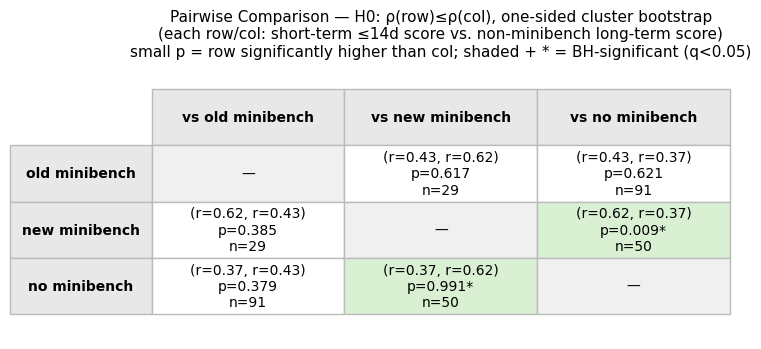

Pairwise comparisons: H0: rho(row) <= rho(col), one-sided cluster bootstrap
(each period has 2 tests -- one vs. each other period; small p = row's rho is significantly higher)
BH check across the 3 unique pairs: 1/3 significant after correction (raw: 1/3)
'*' = significant after BH correction (q<0.05, shared by both directional readouts of a pair)


,vs old minibench,vs new minibench,vs no minibench
old minibench,—,p=0.617 (n=29),p=0.621 (n=91)
new minibench,p=0.385 (n=29),—,p=0.009* (n=50)
no minibench,p=0.379 (n=91),p=0.991* (n=50),—



HTML source (copy/paste into blog):

<table style="border-collapse:collapse;font-family:sans-serif;font-size:14px;">
<thead><tr><th style="border:1px solid #999;padding:6px 10px;background:#eee;text-align:center;"></th><th style="border:1px solid #999;padding:6px 10px;background:#eee;text-align:center;">vs old minibench</th><th style="border:1px solid #999;padding:6px 10px;background:#eee;text-align:center;">vs new minibench</th><th style="border:1px solid #999;padding:6px 10px;background:#eee;text-align:center;">vs no minibench</th></tr></thead>
<tbody>
<tr><td style="border:1px solid #999;padding:6px 10px;text-align:left;">old minibench</td><td style="border:1px solid #999;padding:6px 10px;text-align:center;">—</td><td style="border:1px solid #999;padding:6px 10px;text-align:center;">p=0.617 (n=29)</td><td style="border:1px solid #999;padding:6px 10px;text-align:center;">p=0.621 (n=91)</td></tr>
<tr><td style="border:1px solid #999;padding:6px 10px;text-align:left;">new minibench</t

Condition,r,95% CI,n
old minibench,0.433,"[0.230, 0.600]",91
new minibench,0.624,"[0.416, 0.781]",55
no minibench,0.366,"[0.201, 0.504]",120



HTML source (copy/paste into blog):

<table style="border-collapse:collapse;font-family:sans-serif;font-size:14px;">
<caption>Point estimates</caption>
<thead><tr><th style="border:1px solid #999;padding:6px 10px;background:#eee;text-align:center;">Condition</th><th style="border:1px solid #999;padding:6px 10px;background:#eee;text-align:center;">r</th><th style="border:1px solid #999;padding:6px 10px;background:#eee;text-align:center;">95% CI</th><th style="border:1px solid #999;padding:6px 10px;background:#eee;text-align:center;">n</th></tr></thead>
<tbody>
<tr><td style="border:1px solid #999;padding:6px 10px;text-align:left;">old minibench</td><td style="border:1px solid #999;padding:6px 10px;text-align:center;">0.433</td><td style="border:1px solid #999;padding:6px 10px;text-align:center;">[0.230, 0.600]</td><td style="border:1px solid #999;padding:6px 10px;text-align:center;">91</td></tr>
<tr><td style="border:1px solid #999;padding:6px 10px;text-align:left;">new minibench</td><

In [18]:
# --- 0-14 day vs. >14 day aggregate comparison -------------------------------
# Reuses fmt_p, fmt_p_sig, single_bootstrap_rho, min_questions_per_bin
# from the correlation-matrix cell above; self-contained otherwise.

AGG_LABELS = ["SHORT", "LONG"]

def build_agg_pq(data):
    per_question = data.groupby([_forecaster, "question_id"])[_baseline_score].mean()
    pq = {f: s.values for f, s in per_question.groupby(level=0)}
    return {f: arr for f, arr in pq.items() if len(arr) >= min_questions_per_bin}

_short_mask = all_types_baseline_reduced[_delta_forecast_til_close] <= 14
_long_mask = all_types_baseline_reduced[_delta_forecast_til_close] > 14

long_nonmb_pq = build_agg_pq(all_types_baseline_reduced[_long_mask & (all_types_baseline_reduced["minibench_type"] == "non_minibench")])

AGG_CONDITIONS = [
    ("old minibench", "old_minibench"),
    ("new minibench", "new_minibench"),
    ("no minibench",  "non_minibench"),
]
agg_pq = {}  # name -> {"SHORT": {...}, "LONG": {...}}  (LONG is the SAME object for every condition)
for name, mb_type in AGG_CONDITIONS:
    short_pq = build_agg_pq(all_types_baseline_reduced[_short_mask & (all_types_baseline_reduced["minibench_type"] == mb_type)])
    agg_pq[name] = {"SHORT": short_pq, "LONG": long_nonmb_pq}

def paired_diff_bootstrap_agg(pq_A, pq_B, common, n_boot, rng):
    """Same shared-draw logic as the correlation-matrix cell's paired
    comparisons: LONG is identical data for every condition, so it's
    resampled once per replicate (one shared index draw) and reused for
    both rho calculations, instead of independently re-randomizing a column
    that isn't actually two independent samples. Per-forecaster values are
    exact per-question means, not an inner resample -- see
    single_bootstrap_rho."""
    a = np.array([pq_A["SHORT"][f].mean() for f in common])
    b = np.array([pq_B["SHORT"][f].mean() for f in common])
    l = np.array([pq_A["LONG"][f].mean() for f in common])  # pq_A["LONG"] is pq_B["LONG"]: same object
    n = len(common)
    diff = np.empty(n_boot)
    idx_all = rng.integers(0, n, size=(n_boot, n))
    for r in range(n_boot):
        idx = idx_all[r]
        rho_a = stats.spearmanr(a[idx], l[idx]).statistic
        rho_b = stats.spearmanr(b[idx], l[idx]).statistic
        diff[r] = rho_a - rho_b
    return diff

n_boot_agg = 2000
rng_agg = np.random.default_rng(3)

# Point estimates + own-condition bootstrap CI (printed below the matrix).
agg_results = {}
for name, _ in AGG_CONDITIONS:
    common = sorted(set(agg_pq[name]["SHORT"]) & set(agg_pq[name]["LONG"]))
    r = stats.spearmanr(
        [agg_pq[name]["SHORT"][f].mean() for f in common],
        [agg_pq[name]["LONG"][f].mean() for f in common],
    ).statistic
    boot = single_bootstrap_rho("SHORT", "LONG", agg_pq[name], common, n_boot_agg, rng_agg)
    lo, hi = np.percentile(boot, [2.5, 97.5])
    agg_results[name] = {"r": r, "n": len(common), "lo": lo, "hi": hi}

# Pairwise comparisons: for each ordered pair (row, col), H0: rho(row) - rho(col) <= 0.
# The two directional p-values for a given unordered pair (p_A>B and p_B>A) are
# complementary readouts of the SAME underlying test (they sum to ~1), not two
# independent hypotheses -- so BH correction runs across the 3 unique pairs
# (using each pair's smaller/"primary" p, i.e. whichever direction the data
# actually points), and the resulting q is shared by both directional cells of
# that pair rather than computed separately for each.
names = [n for n, _ in AGG_CONDITIONS]
pair_p = {}  # (row, col) -> p-value for H0: rho(row) <= rho(col)
unique_pairs = []
for i, A in enumerate(names):
    for B in names[i + 1:]:
        common = sorted(set(agg_pq[A]["SHORT"]) & set(agg_pq[B]["SHORT"]) & set(agg_pq[A]["LONG"]))
        diff = paired_diff_bootstrap_agg(agg_pq[A], agg_pq[B], common, n_boot_agg, rng_agg)
        p_A_gt_B = float((diff <= 0).mean())
        p_B_gt_A = float((diff >= 0).mean())
        pair_p[(A, B)] = {"p": p_A_gt_B, "n": len(common)}
        pair_p[(B, A)] = {"p": p_B_gt_A, "n": len(common)}
        unique_pairs.append((A, B))

primary_p = [min(pair_p[(A, B)]["p"], pair_p[(B, A)]["p"]) for A, B in unique_pairs]
primary_q = bh_adjust(primary_p)
for (A, B), q in zip(unique_pairs, primary_q):
    pair_p[(A, B)]["q"] = q
    pair_p[(B, A)]["q"] = q

# --- Plot: pairwise comparison rendered as a table (not a color heatmap) ----
# A plain table reads more precisely than a color scale for exact p-values --
# no risk of misjudging a shade of orange -- at the cost of losing the
# at-a-glance color signal the heatmap gave. Significant cells (q<0.05) are
# marked with '*' and a light shaded background instead of a color gradient,
# and the diagonal is dashed out since a self-comparison is undefined.
# Each cell also shows (r_row, r_col) -- the two correlation coefficients the
# p-value is actually comparing -- so the test result can be read alongside
# the effect size it's testing rather than requiring a lookup in the point
# estimates printed below.
cell_text = []
cell_colors = []
for A in names:
    row_text = []
    row_colors = []
    for B in names:
        if A == B:
            row_text.append("—")
            row_colors.append("#f0f0f0")
        else:
            s = pair_p[(A, B)]
            is_sig = s.get("q") is not None and not np.isnan(s["q"]) and s["q"] < 0.05
            r_pair = f"(r={agg_results[A]['r']:.2f}, r={agg_results[B]['r']:.2f})"
            row_text.append(f"{r_pair}\np={fmt_p_sig(s['p'], is_sig)}\nn={s['n']}")
            row_colors.append("#d9f0d3" if is_sig else "white")
    cell_text.append(row_text)
    cell_colors.append(row_colors)

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.axis("off")
tbl = ax.table(
    cellText=cell_text,
    cellColours=cell_colors,
    rowLabels=names,
    colLabels=[f"vs {n}" for n in names],
    cellLoc="center",
    rowLoc="center",
    loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 3.4)
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor("#bbbbbb")
    if row == 0 or col == -1:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#e8e8e8")

ax.set_title(
    "Pairwise Comparison — H0: ρ(row)≤ρ(col), one-sided cluster bootstrap\n"
    "(each row/col: short-term ≤14d score vs. non-minibench long-term score)\n"
    "small p = row significantly higher than col; shaded + * = BH-significant (q<0.05)",
    fontsize=11,
)
plt.tight_layout()
plt.show()

# --- Pairwise comparison table ------------------------------------------------
n_sig_raw_agg = sum(min(pair_p[(A, B)]["p"], pair_p[(B, A)]["p"]) < 0.05 for A, B in unique_pairs)
n_sig_bh_agg = sum(q < 0.05 for q in primary_q if not np.isnan(q))
print("Pairwise comparisons: H0: rho(row) <= rho(col), one-sided cluster bootstrap")
print("(each period has 2 tests -- one vs. each other period; small p = row's rho is significantly higher)")
print(f"BH check across the 3 unique pairs: {n_sig_bh_agg}/3 significant after correction (raw: {n_sig_raw_agg}/3)")
print("'*' = significant after BH correction (q<0.05, shared by both directional readouts of a pair)")

# Reuses render_html_table (defined in the focused-matrix cell above).
agg_matrix_headers = [""] + [f"vs {n}" for n in names]
agg_matrix_rows = []
for A in names:
    row_cells = [A]
    for B in names:
        if A == B:
            row_cells.append("—")
        else:
            pair_stat = pair_p[(A, B)]
            is_sig = pair_stat.get("q") is not None and not np.isnan(pair_stat["q"]) and pair_stat["q"] < 0.05
            row_cells.append(f"p={fmt_p_sig(pair_stat['p'], is_sig)} (n={pair_stat['n']})")
    agg_matrix_rows.append(row_cells)

agg_matrix_html = render_html_table(agg_matrix_headers, agg_matrix_rows)
display(HTML(agg_matrix_html))
print("\nHTML source (copy/paste into blog):\n")
print(agg_matrix_html)

agg_points_headers = ["Condition", "r", "95% CI", "n"]
agg_points_rows = [
    (n, f"{agg_results[n]['r']:.3f}", f"[{agg_results[n]['lo']:.3f}, {agg_results[n]['hi']:.3f}]", str(agg_results[n]['n']))
    for n in names
]
agg_points_html = render_html_table(agg_points_headers, agg_points_rows, caption="Point estimates")
display(HTML(agg_points_html))
print("\nHTML source (copy/paste into blog):\n")
print(agg_points_html)


In [19]:
# --- BCa audit: the pairwise SHORT-vs-LONG comparison table (old/new/no minibench) ---
# Same idea as the BCa audit cell in the correlation-matrices section above,
# applied here instead. This table's test is a *difference* of two
# correlations (rho_A - rho_B, via paired_diff_bootstrap_agg). Even in this
# debiased copy (no nested resample -- see the note above), running this
# audit still flips 2 of 3 comparisons under BCa. That's expected: BCa's
# acceleration term picks up genuine skew in the sampling distribution of a
# correlation *difference* whenever the two conditions being compared have
# very unequal sample sizes -- "old minibench"/"new minibench" have far fewer
# forecasters and per-question observations than "no minibench" in the
# relevant pairs (n=29-55 vs. n=91) -- and that skew is a real property of
# this comparison, not an artifact of the resample bug fixed above.
#
# Reuses bca_one_sided_pvalue/bca_acceleration from the BCa audit cell above
# (correlation-matrices section), and names/agg_pq/agg_results/
# paired_diff_bootstrap_agg/n_boot_agg from the cell immediately above this
# one; self-contained otherwise. Read-only -- doesn't change any number
# reported elsewhere.

def jackknife_diff_agg(pq_A, pq_B, common):
    """Leave-one-forecaster-out (rho_A - rho_B) on the exact per-forecaster
    means -- feeds BCa's acceleration term for this paired-comparison test."""
    a_short = np.array([pq_A["SHORT"][f].mean() for f in common])
    b_short = np.array([pq_B["SHORT"][f].mean() for f in common])
    long_ = np.array([pq_A["LONG"][f].mean() for f in common])  # same object as pq_B["LONG"]
    n = len(common)
    out = np.empty(n)
    for i in range(n):
        keep = np.arange(n) != i
        rho_a = stats.spearmanr(a_short[keep], long_[keep]).statistic
        rho_b = stats.spearmanr(b_short[keep], long_[keep]).statistic
        out[i] = rho_a - rho_b
    return out


agg_pair_rows = []
rng_agg_audit = np.random.default_rng(3)
for i, A in enumerate(names):
    for B in names[i + 1:]:
        common = sorted(set(agg_pq[A]["SHORT"]) & set(agg_pq[B]["SHORT"]) & set(agg_pq[A]["LONG"]))
        diff = paired_diff_bootstrap_agg(agg_pq[A], agg_pq[B], common, n_boot_agg, rng_agg_audit)
        observed_diff = agg_results[A]["r"] - agg_results[B]["r"]
        jack = jackknife_diff_agg(agg_pq[A], agg_pq[B], common)

        p_raw_A_gt_B = float((diff <= 0).mean())
        p_raw_B_gt_A = float((diff >= 0).mean())
        # B>A is audited by negating the statistic rather than re-deriving a
        # second BCa formula -- z0/acceleration computed on the negated
        # series correctly gives the mirrored one-sided correction.
        p_bca_A_gt_B = bca_one_sided_pvalue(diff, observed_diff, jack, null_value=0.0)
        p_bca_B_gt_A = bca_one_sided_pvalue(-diff, -observed_diff, -jack, null_value=0.0)

        agg_pair_rows.append({
            "pair": f"{A} vs {B}", "n": len(common),
            "r_A": agg_results[A]["r"], "r_B": agg_results[B]["r"], "observed_diff": observed_diff,
            "p_raw(A>B)": p_raw_A_gt_B, "p_bca(A>B)": p_bca_A_gt_B,
            "p_raw(B>A)": p_raw_B_gt_A, "p_bca(B>A)": p_bca_B_gt_A,
        })

agg_audit_df = pd.DataFrame(agg_pair_rows)

# BH correction across the 3 unique pairs, using each pair's primary
# (smaller/directionally-correct) p -- matches the original table's own
# correction scope, computed separately for the raw and BCa versions.
agg_audit_df["p_raw_primary"] = agg_audit_df[["p_raw(A>B)", "p_raw(B>A)"]].min(axis=1)
agg_audit_df["p_bca_primary"] = agg_audit_df[["p_bca(A>B)", "p_bca(B>A)"]].min(axis=1)
agg_audit_df["q_raw_primary"] = bh_adjust(agg_audit_df["p_raw_primary"].values)
agg_audit_df["q_bca_primary"] = bh_adjust(agg_audit_df["p_bca_primary"].values)
agg_audit_df["raw_sig"] = agg_audit_df["q_raw_primary"] < 0.05
agg_audit_df["bca_sig"] = agg_audit_df["q_bca_primary"] < 0.05
agg_audit_df["flips"] = agg_audit_df["raw_sig"] != agg_audit_df["bca_sig"]

print("BCa-corrected audit of the pairwise SHORT-vs-LONG comparison table:")
print(agg_audit_df.to_string(index=False, formatters={
    "r_A": "{:.3f}".format, "r_B": "{:.3f}".format, "observed_diff": "{:.3f}".format,
    "p_raw(A>B)": fmt_p, "p_bca(A>B)": fmt_p, "p_raw(B>A)": fmt_p, "p_bca(B>A)": fmt_p,
    "p_raw_primary": fmt_p, "p_bca_primary": fmt_p, "q_raw_primary": fmt_p, "q_bca_primary": fmt_p,
}))
n_flip_agg = int(agg_audit_df["flips"].sum())
print(f"\n{n_flip_agg} of {len(agg_audit_df)} pairwise comparisons flip significance (q<0.05) under the BCa correction.")
if n_flip_agg:
    print("Flipped comparisons:")
    print(agg_audit_df[agg_audit_df["flips"]].to_string(index=False))

BCa-corrected audit of the pairwise SHORT-vs-LONG comparison table:
                          pair  n   r_A   r_B observed_diff p_raw(A>B) p_bca(A>B) p_raw(B>A) p_bca(B>A) p_raw_primary p_bca_primary q_raw_primary q_bca_primary  raw_sig  bca_sig  flips
old minibench vs new minibench 29 0.433 0.624        -0.191      0.602      0.999      0.400      0.001         0.400         0.001         0.400         0.002    False     True   True
 old minibench vs no minibench 91 0.433 0.366         0.067      0.631      0.041      0.368      0.959         0.368         0.041         0.400         0.041    False     True   True
 new minibench vs no minibench 50 0.624 0.366         0.258      0.006      <.001      0.994      1.000         0.006         <.001         0.018         <.001     True     True  False

2 of 3 pairwise comparisons flip significance (q<0.05) under the BCa correction.
Flipped comparisons:
                          pair  n      r_A      r_B  observed_diff  p_raw(A>B)  p_bca(A>B

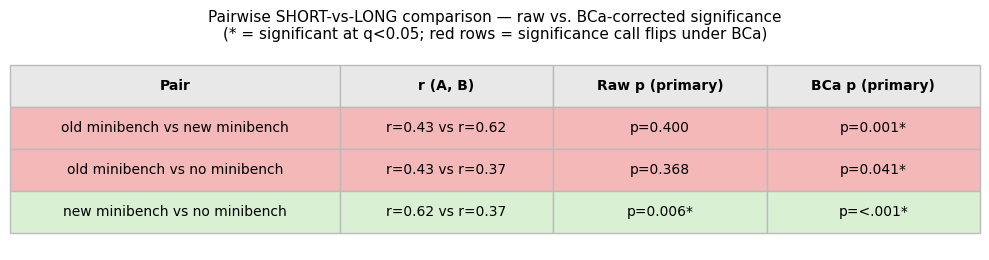

In [20]:
# --- Chart: raw vs. BCa-corrected significance, pairwise SHORT-vs-LONG table ---
# Rendered the same way as the pairwise-comparison table above (a plain
# matplotlib table rather than a color heatmap, for exact readability), but
# showing the raw and BCa-corrected primary p-value side by side so the two
# comparisons that flip significance are visible at a glance instead of
# buried in printed output. Reuses agg_audit_df from the BCa audit cell
# immediately above; self-contained otherwise.

flip_color = "#f4b8b8"
sig_color = "#d9f0d3"

cell_text_bca = []
cell_colors_bca = []
for _, row in agg_audit_df.iterrows():
    raw_txt = f"p={fmt_p(row['p_raw_primary'])}" + ("*" if row["raw_sig"] else "")
    bca_txt = f"p={fmt_p(row['p_bca_primary'])}" + ("*" if row["bca_sig"] else "")
    cell_text_bca.append([
        row["pair"],
        f"r={row['r_A']:.2f} vs r={row['r_B']:.2f}",
        raw_txt,
        bca_txt,
    ])
    color = flip_color if row["flips"] else ("white" if not row["raw_sig"] and not row["bca_sig"] else sig_color)
    cell_colors_bca.append([color] * 4)

fig_bt, ax_bt = plt.subplots(figsize=(10, 0.9 + 0.6 * len(agg_audit_df)))
ax_bt.axis("off")
tbl_bca = ax_bt.table(
    cellText=cell_text_bca,
    cellColours=cell_colors_bca,
    colLabels=["Pair", "r (A, B)", "Raw p (primary)", "BCa p (primary)"],
    cellLoc="center",
    loc="center",
    colWidths=[0.34, 0.22, 0.22, 0.22],
)
tbl_bca.auto_set_font_size(False)
tbl_bca.set_fontsize(10)
tbl_bca.scale(1, 2.6)
for (row_i, col_i), cell in tbl_bca.get_celld().items():
    cell.set_edgecolor("#bbbbbb")
    if row_i == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#e8e8e8")

ax_bt.set_title(
    "Pairwise SHORT-vs-LONG comparison — raw vs. BCa-corrected significance\n"
    "(* = significant at q<0.05; red rows = significance call flips under BCa)",
    fontsize=11,
)
plt.tight_layout()
plt.show()